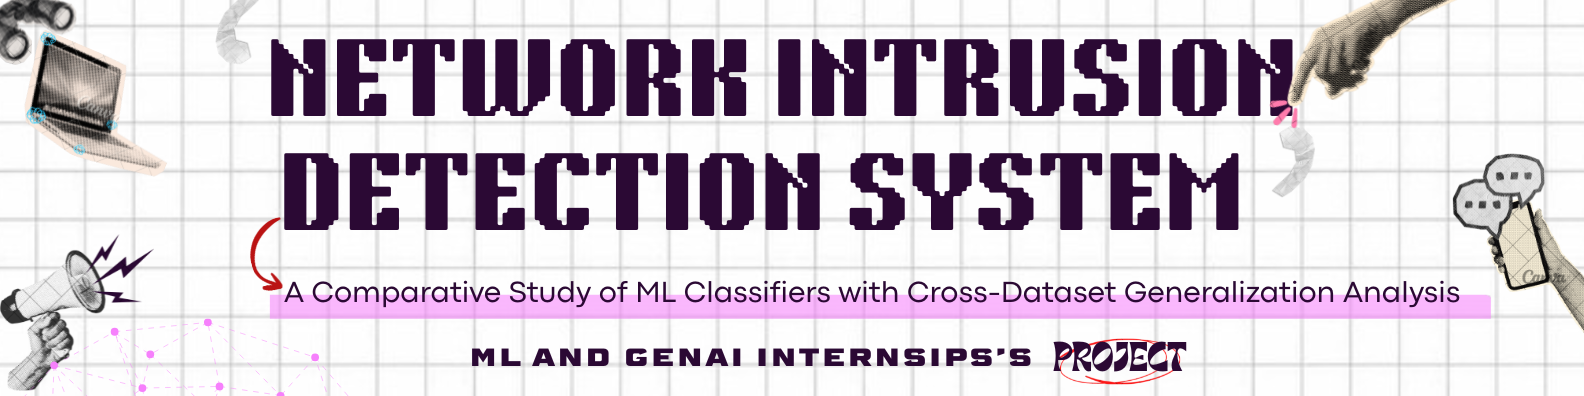

In [6]:
from IPython.display import Image, display
display(Image('/kaggle/input/datasets/sneharani20/banner/Black and Orange Aesthetic LinkedIn Banner.png'))

# Members and their Enrollment Nos

 
> **1.Sneha Rani-12601182025**

> **3.Sanskriti Maurya-11301182025**

> **2.Sneha Verma-06401192025**







# The Problem

****Network security is critical in today's interconnected digital world. Intrusion Detection Systems (IDS) are designed to identify unauthorized access attempts and malicious network activity. Traditional rule-based IDS fail to detect novel and evolving attack patterns, making machine learning approaches essential for modern cybersecurity.****

Most existing IDS research focuses on single-dataset evaluation — models are trained and tested on the same dataset (e.g., NSL-KDD). This approach has a critical flaw:

Why single-dataset evaluation is misleading:

**As single-dataset evaluation is misleading:**
> A model achieving 99% accuracy on NSL-KDD might perform poorly on real-world network traffic (CICIDS2017, KDD99)



**Why this matters:**
> Security professionals need IDS models that generalize across different network environments and time periods.

# Our Contribution
**We explicitly test cross-dataset generalization — train models on NSL-KDD (2009), test on KDD99 (original, 1999). This reveals the true robustness of different ML algorithms.**

*Rather than simply building model's  accuracy on one dataset we will try to compare multiple algorithms rather than just one and as many research papers higlighted the weakness in recent NIDS models ,We will try to explicitly tests generalization across two datasets of different vintages to partially close the gap.*

**The notebook includes code for data loading, exploratory data analysis (EDA), preprocessing, and model training and evaluation on three network intrusion detection datasets: NSL-KDD, CICIDS2017, and KDD99. The analysis focuses on building and evaluating binary classification models to distinguish between normal and attack traffic.**

# Our USP

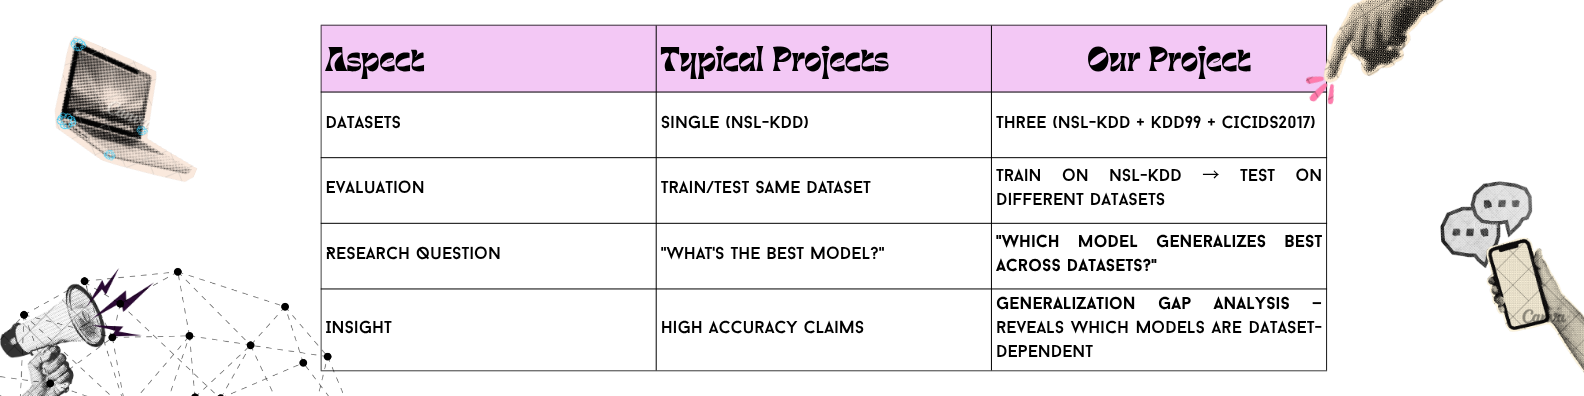

In [7]:
from IPython.display import Image, display
display(Image('/kaggle/input/datasets/sneharani20/banner2/Black and Orange Aesthetic LinkedIn Banner (1).png'))

> **Data Loading and Inspection**

The notebook begins by importing necessary libraries and loading the NSL-KDD training and testing datasets.

It performs initial data exploration, displaying the dataset's shape and summary statistics, and checking for missing values and duplicates (finding none).

A difficulty column, present only in the original NSL-KDD data, is noted but later dropped.

>**Exploratory Data Analysis (EDA)**

Class Distribution: Visualizes the distribution of the binary_label (Normal vs. Attack) and the multi-class attack_type (DoS, Probe, R2L, U2R) in both training and testing sets. The attack_type is derived from the label column using a custom mapping function.

Feature Distributions: Analyzes the distribution of key features like src_bytes, dst_bytes, service, protocol_type, and flag using bar plots and Kernel Density Estimates (KDE) to understand their relationship with normal and attack traffic.

Correlation Analysis: Generates a heatmap of feature correlations to identify highly correlated features.

Service and Attack Type Analysis: Examines the relationship between services (service column) and attack types, visualizing which services are most commonly associated with attacks.

> **Data Preprocessing**

Feature Encoding: Categorical features (protocol_type, service, flag) are encoded using LabelEncoder.

Target Encoding: A binary label (binary_label) is created where normal is mapped to 0 and all attacks to 1. A multi-class target (attack_encoded) is also created based on the attack_type.

Feature Scaling: Numerical features are standardized using StandardScaler.

Feature Selection: The final features set for modeling includes 41 numerical features, excluding label, attack_type, binary_label, attack_encoded, and difficulty. The dataset is split into training and validation sets.

> **Model Training and Evaluation on NSL-KDD**

A wide array of machine learning models are trained and evaluated on the NSL-KDD test set. Models include Naive Bayes, Logistic Regression, Decision Tree, Random Forest, AdaBoost, KNN, LinearSVM, LightGBM, XGBoost, and CatBoost.

**Performance Metrics**: Models are evaluated on Accuracy, Precision, Recall, and F1-Score. The training time for each model is also measured.

T**op Performance**: CatBoost achieves the highest accuracy (80.67%) on the test set, followed closely by XGBoost (80.09%) and LightGBM (79.70%).

**Overfitting Check**: A comparison of train and test accuracies reveals that many models, especially tree-based ones (e.g., Random Forest, Decision Tree, XGBoost), show signs of significant overfitting, with near-perfect training accuracy but significantly lower test accuracy. CatBoost has one of the lowest overfitting gaps (19.25%).

> **Cross-Dataset Evaluation on CICIDS2017**

A 10% sample of the larger CICIDS2017 dataset is preprocessed and used for cross-dataset evaluation.

The models are retrained on the NSL-KDD dataset and tested on the preprocessed CICIDS2017 sample.

**Generalization Performance**: The results show excellent generalization, with most models achieving over 99% accuracy. XGBoost and LightGBM achieve the highest accuracies of 99.89% and 99.88%, respectively. This is a stark contrast to the NSL-KDD results, suggesting that the CICIDS2017 dataset, while larger, may contain patterns more easily learned or that the feature sets and class distributions differ significantly.

> **Cross-Dataset Evaluation on KDD99**

A third dataset, KDD99, which is structurally very similar to NSL-KDD, is used for further cross-dataset testing.

The models trained on NSL-KDD are tested on the KDD99 dataset.

Near-Perfect Accuracy: Most models achieve near-perfect or perfect accuracy on KDD99. XGBoost and Random Forest achieve 100% accuracy. This indicates that the patterns learned by these models generalize extremely well to similar data from the same source (the original KDD Cup 1999 dataset).

> **Results and Insights**

**Cross-Dataset Comparison**: The results highlight a massive performance drop when models are transferred from NSL-KDD to CICIDS2017 (e.g., CatBoost drops from 99.86% to 80.67%), indicating that models are highly sensitive to differences in data distributions between datasets.

**Within-Source Generalization**: Conversely, the high accuracy on KDD99 validates that the models successfully learned the underlying patterns of the KDD'99 data and can generalize well to new samples from the same distribution.

**Model Comparison**: Tree-based models (XGBoost, LightGBM, Random Forest, CatBoost) consistently outperform linear models (Logistic Regression, LinearSVM) and the simple Naive Bayes classifier across all datasets, particularly excelling in terms of accuracy and F1-Score.

#  IMPORT LIBRARIES

*All required libraries imported. Models to be evaluated include traditional ML algorithms and modern gradient boosting frameworks (XGBoost, LightGBM, CatBoost)*

# NSL - KDD DATASET

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
import warnings
import optuna
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree  import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, 
VotingClassifier, GradientBoostingClassifier)
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import BernoulliNB
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFE
import itertools
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from tabulate import tabulate
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import os
import time
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
print("Done_import")

/kaggle/input/datasets/sneharani20/banner2/Black and Orange Aesthetic LinkedIn Banner (1).png
/kaggle/input/datasets/sneharani20/banner/Black and Orange Aesthetic LinkedIn Banner.png
/kaggle/input/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed/cicids2017_cleaned.csv
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/training_attack_types
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data.corrected
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.newtestdata_10_percent_unlabeled.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.testdata.unlabeled.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/corrected.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data_10_percent.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.names
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data_10_percent_corrected
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/typo-corr

# Column Names & Data Loading

*The NSL-KDD dataset contains 41 features + 2 target columns (label and difficulty). Training set: 125,973 samples, Test set: 22,544 samples.*

In [35]:
col_names = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"]

train_df = pd.read_csv('/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt', names=col_names)
test_df = pd.read_csv('/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt', names=col_names)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
train_df.head()

Train: (125973, 43)
Test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# Dataset Information

*Features include 24 integer, 15 float, and 4 categorical object columns. There are no missing values, which simplifies preprocessing.*

In [36]:
train_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [37]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


#  Statistical Summary 

> *Severe feature scale differences exist (e.g., src_bytes ranges from 0 to 1.37e9), necessitating standardization before modeling.*

> *The dataset has 3 protocol types, 70 services, 11 flag types, and 23 attack categories. Most common service is 'http' (40,338 instances).*

In [38]:
train_df.describe(include='object')

,protocol_type,service,flag,label
count,125973,125973,125973,125973
unique,3,70,11,23
top,tcp,http,SF,normal
freq,102689,40338,74945,67343


In [39]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# Binary Label Creation & Visualization

*Training set: 67,343 (53.5%) normal vs 58,630 (46.5%) attacks. Test set: 9,711 (43.1%) normal vs 12,833 (56.9%) attacks. This demonstrates class imbalance that could affect model performance.*

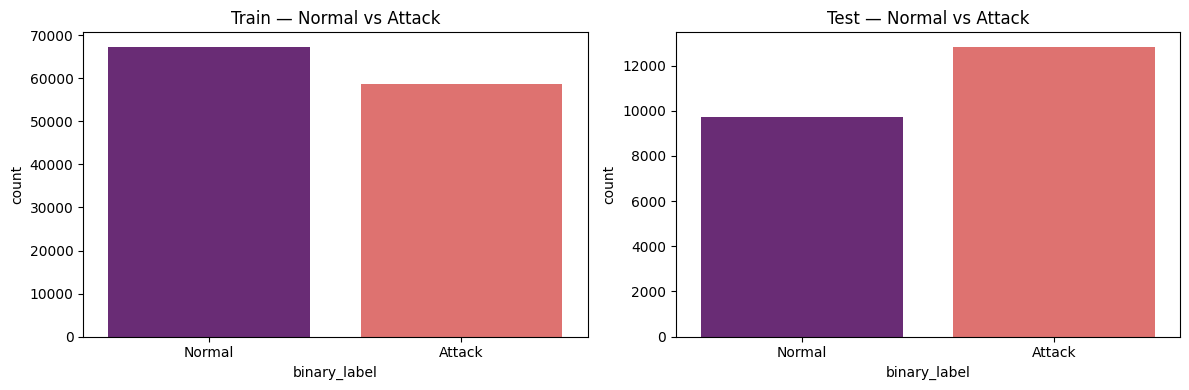

Train: binary_label
0    67343
1    58630
Name: count, dtype: int64

Test: binary_label
1    12833
0     9711
Name: count, dtype: int64


In [40]:
#  CLASSIFY ATTACK OR NOT 
# Binary label — Normal=0, Attack=1
train_df['binary_label'] = train_df['label'].apply(
    lambda x: 0 if x == 'normal' else 1)
test_df['binary_label'] = test_df['label'].apply(
    lambda x: 0 if x == 'normal' else 1)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x='binary_label', data=train_df, 
              palette='magma', ax=axes[0])
axes[0].set_title('Train — Normal vs Attack')
axes[0].set_xticklabels(['Normal', 'Attack'])

sns.countplot(x='binary_label', data=test_df, 
              palette='magma', ax=axes[1])
axes[1].set_title('Test — Normal vs Attack')
axes[1].set_xticklabels(['Normal', 'Attack'])

plt.tight_layout()
plt.show()

print("Train:", train_df['binary_label'].value_counts())
print("\nTest:", test_df['binary_label'].value_counts())

# Attack Distribution 

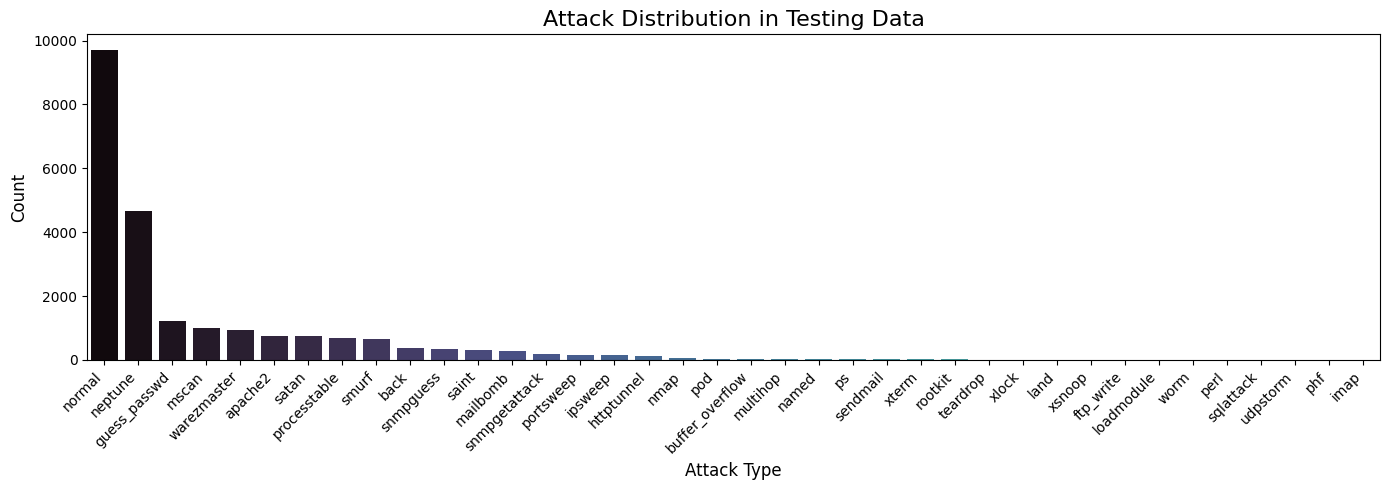

label
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
named                17
ps                   15
sendmail             14
xterm                13
rootkit              13
teardrop             12
xlock                 9
land                  7
xsnoop                4
ftp_write             3
loadmodule            2
worm                  2
perl                  2
sqlattack             2
udpstorm              2
phf                   2
imap                  1
Name: count, dtype: int64


In [41]:
# Attack distribution in Testing data

plt.figure(figsize=(14,5))
test_attack_counts = test_df['label'].value_counts()

sns.barplot(x=test_attack_counts.index, y=test_attack_counts.values, palette='mako')
plt.title('Attack Distribution in Testing Data', fontsize=16)
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(test_attack_counts)

*Neptune (4,657), guess_passwd (1,231), and mscan (996) are the most frequent attacks in test data. The dataset includes 23 unique attack types, which we later map to 5 categories: Normal, DoS, Probe, R2L, U2R.*

# Attack Type Categorization

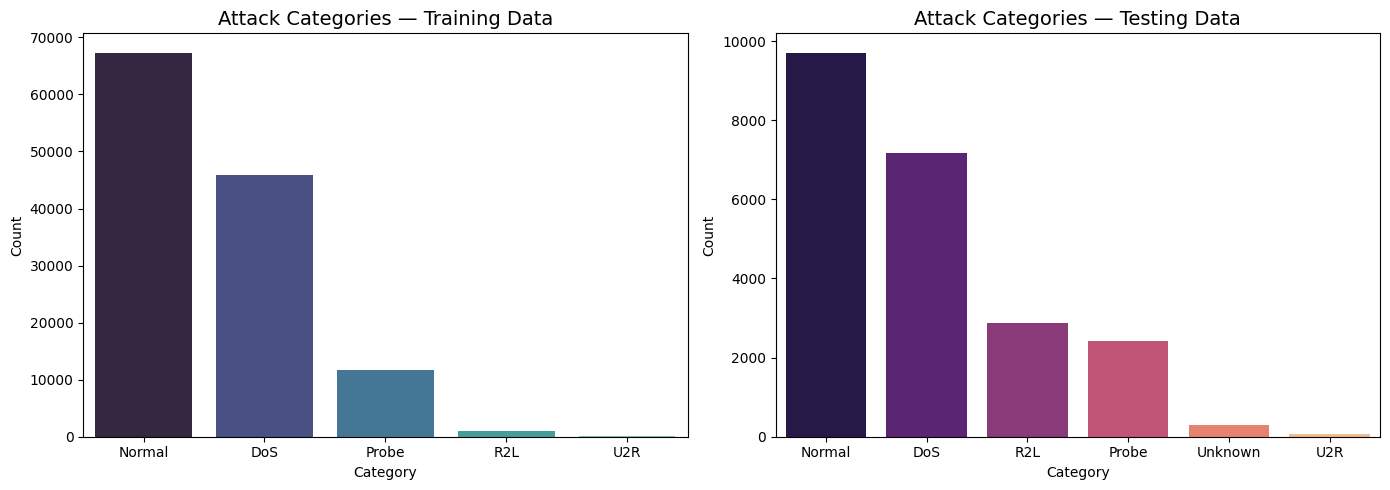

Training Attack Categories:
attack_type
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Testing Attack Categories:
attack_type
Normal     9711
DoS        7167
R2L        2885
Probe      2421
Unknown     293
U2R          67
Name: count, dtype: int64


In [43]:
# Attack TYPE distribution — Normal vs DoS vs Probe vs R2L vs U2R
def map_attack_type(label):
    dos = ['back','land','neptune','pod','smurf','teardrop','apache2',
           'udpstorm','processtable','worm']
    probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
    r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient',
           'warezmaster','sendmail','named','snmpgetattack','snmpguess',
           'xlock','xsnoop','httptunnel']
    u2r = ['buffer_overflow','loadmodule','perl','rootkit','sqlattack',
           'xterm','ps']
    if label == 'normal':
        return 'Normal'
    elif label in dos:
        return 'DoS'
    elif label in probe:
        return 'Probe'
    elif label in r2l:
        return 'R2L'
    elif label in u2r:
        return 'U2R'
    else:
        return 'Unknown'

train_df['attack_type'] = train_df['label'].apply(map_attack_type)
test_df['attack_type'] = test_df['label'].apply(map_attack_type)

# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Train
train_type_counts = train_df['attack_type'].value_counts()
sns.barplot(x=train_type_counts.index, y=train_type_counts.values, 
            palette='mako', ax=axes[0])
axes[0].set_title('Attack Categories — Training Data', fontsize=14)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')

# Test  
test_type_counts = test_df['attack_type'].value_counts()
sns.barplot(x=test_type_counts.index, y=test_type_counts.values, 
            palette='magma', ax=axes[1])
axes[1].set_title('Attack Categories — Testing Data', fontsize=14)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Training Attack Categories:")
print(train_type_counts)
print("\nTesting Attack Categories:")
print(test_type_counts)

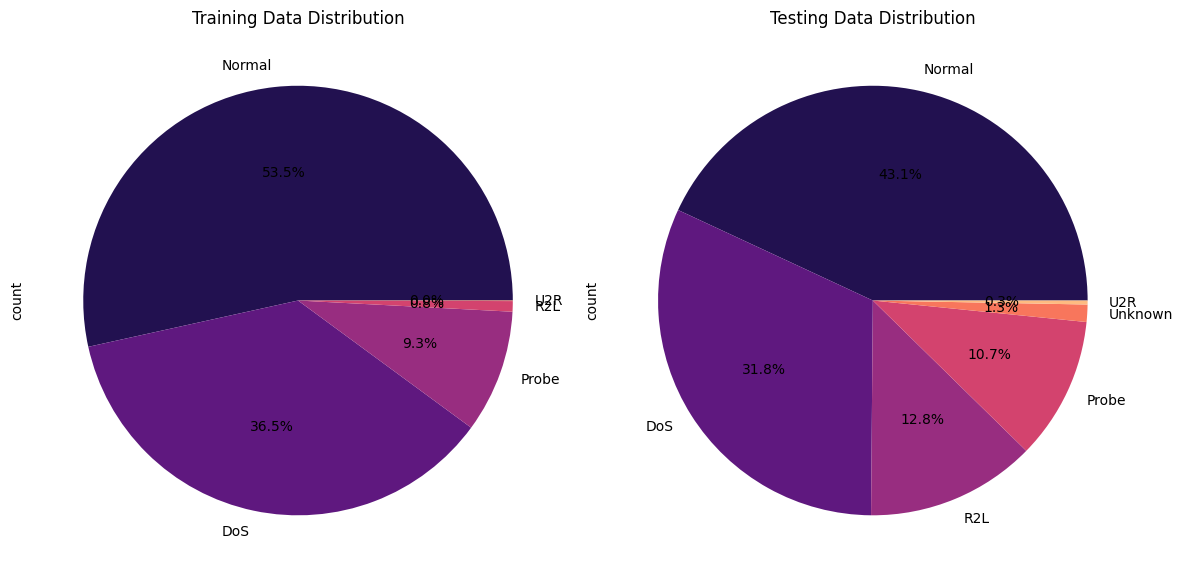

In [44]:
# Pie chart 
fig, axes = plt.subplots(1, 2, figsize=(12,6))

train_df['attack_type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0], 
    colors=sns.color_palette('magma'),
    title='Training Data Distribution')

test_df['attack_type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[1],
    colors=sns.color_palette('magma'),
    title='Testing Data Distribution')

plt.tight_layout()
plt.show()

In [45]:
train_df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

# Duplicate Removal

In [46]:
#Duplicates rows
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

# Drop duplicates
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

print("\nAfter removing duplicates:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train duplicates: 0
Test duplicates: 0

After removing duplicates:
Train shape: (125973, 45)
Test shape: (22544, 45)


# Missing Values Check

In [47]:
# Missing values check
print("=== TRAIN MISSING VALUES ===")
print(train_df.isnull().sum())

print("\n=== TEST MISSING VALUES ===")
print(test_df.isnull().sum())

=== TRAIN MISSING VALUES ===
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate 

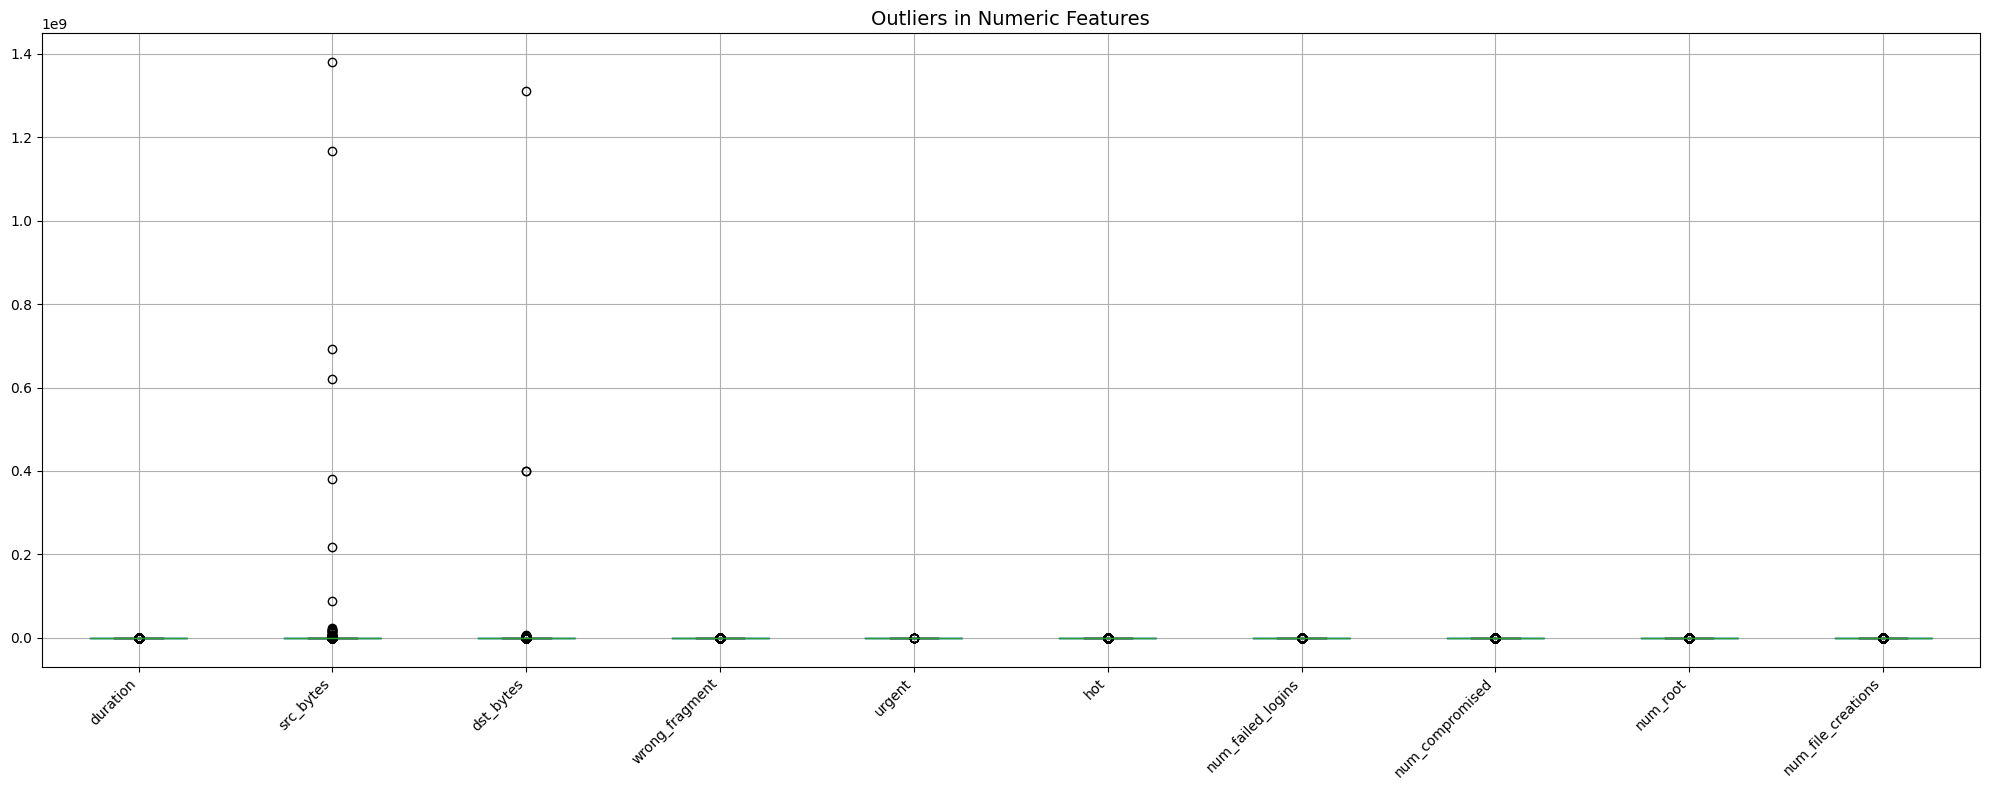

In [48]:
#Outliers
plt.figure(figsize=(20,8))
numeric_cols = ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 
                'urgent', 'hot', 'num_failed_logins', 'num_compromised',
                'num_root', 'num_file_creations']

train_df[numeric_cols].boxplot()
plt.title('Outliers in Numeric Features', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

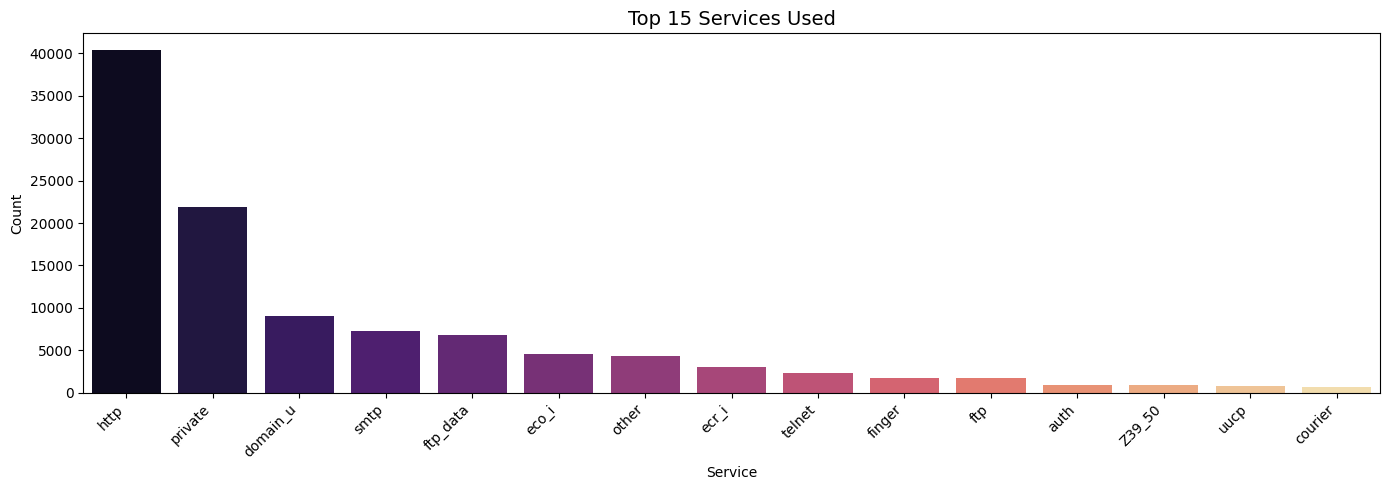

In [49]:
#SERVICE USED GENERAL
plt.figure(figsize=(14,5))
top_services = train_df['service'].value_counts().head(15)
sns.barplot(x=top_services.index, y=top_services.values, palette='magma')
plt.title('Top 15 Services Used', fontsize=14)
plt.xlabel('Service')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

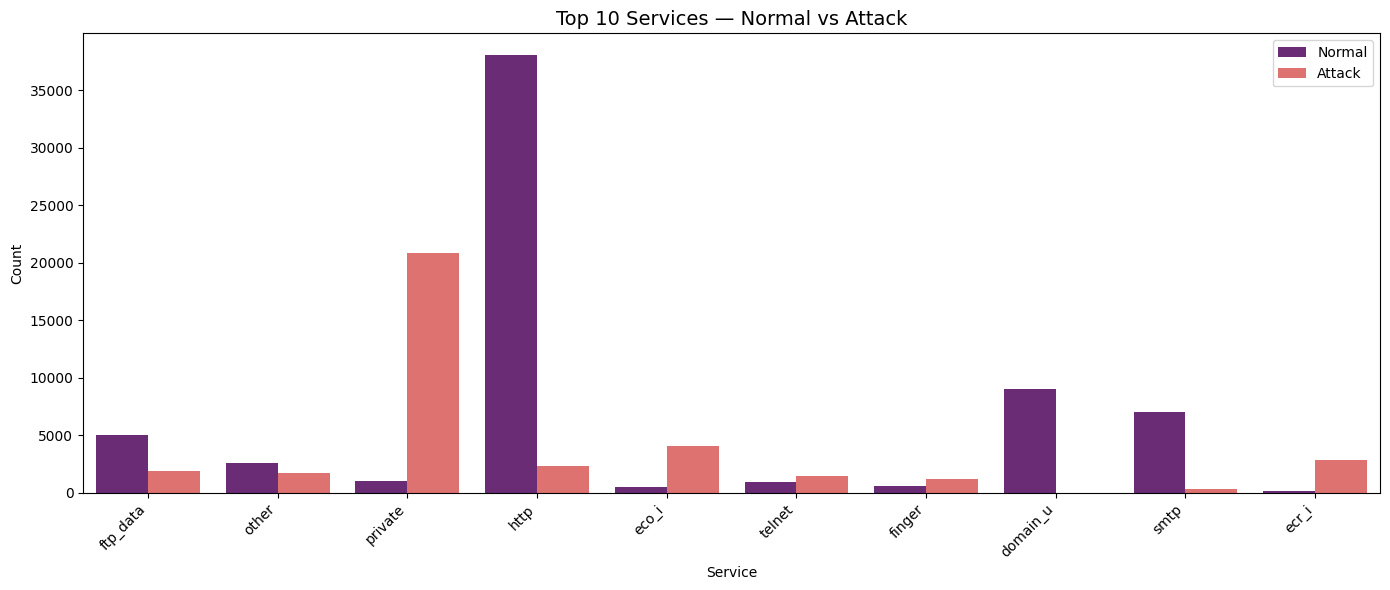

In [50]:
#SERVICE EFFECT ON ATTACKS
plt.figure(figsize=(14,6))
top_10_services = train_df['service'].value_counts().head(10).index
service_attack = train_df[train_df['service'].isin(top_10_services)]

sns.countplot(x='service', hue='binary_label', 
              data=service_attack, palette='magma')
plt.title('Top 10 Services — Normal vs Attack', fontsize=14)
plt.xlabel('Service')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Normal', 'Attack'])
plt.tight_layout()
plt.show()

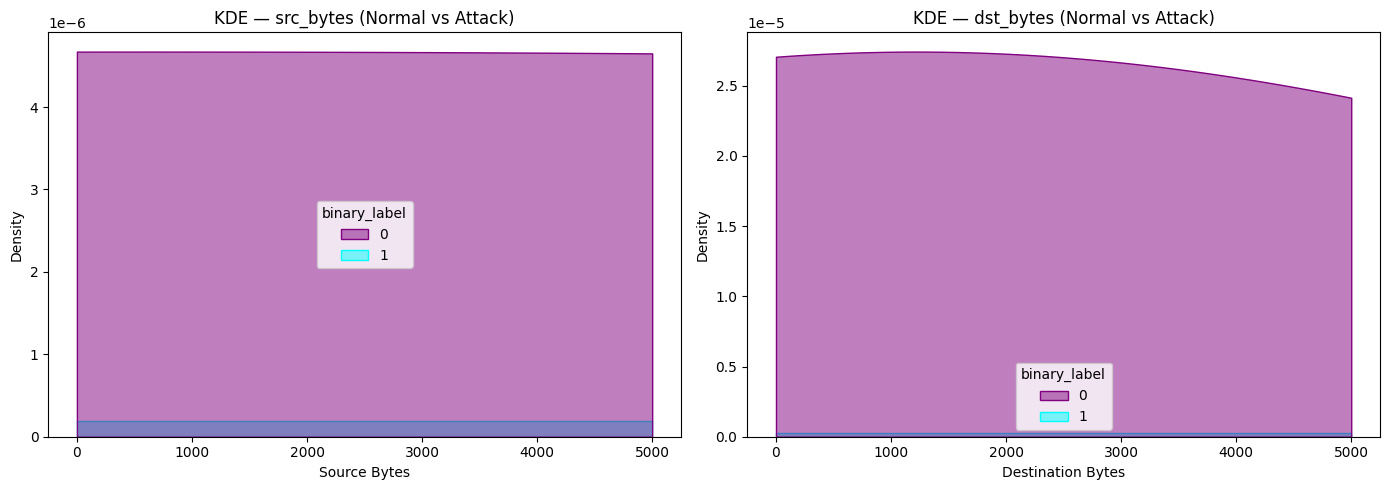

In [76]:
#KDE—Kernel Density Estimate
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# src_bytes distribution
sns.kdeplot(data=train_df, x='src_bytes', hue='binary_label', 
            ax=axes[0], fill=True, alpha=0.5,
            palette=['purple','aqua'], clip=(0, 5000))
axes[0].set_title('KDE — src_bytes (Normal vs Attack)')
axes[0].set_xlabel('Source Bytes')

# dst_bytes distribution  
sns.kdeplot(data=train_df, x='dst_bytes', hue='binary_label',
            ax=axes[1], fill=True, alpha=0.5,
            palette=['purple','aqua'], clip=(0, 5000))
axes[1].set_title('KDE — dst_bytes (Normal vs Attack)')
axes[1].set_xlabel('Destination Bytes')

plt.tight_layout()
plt.show()

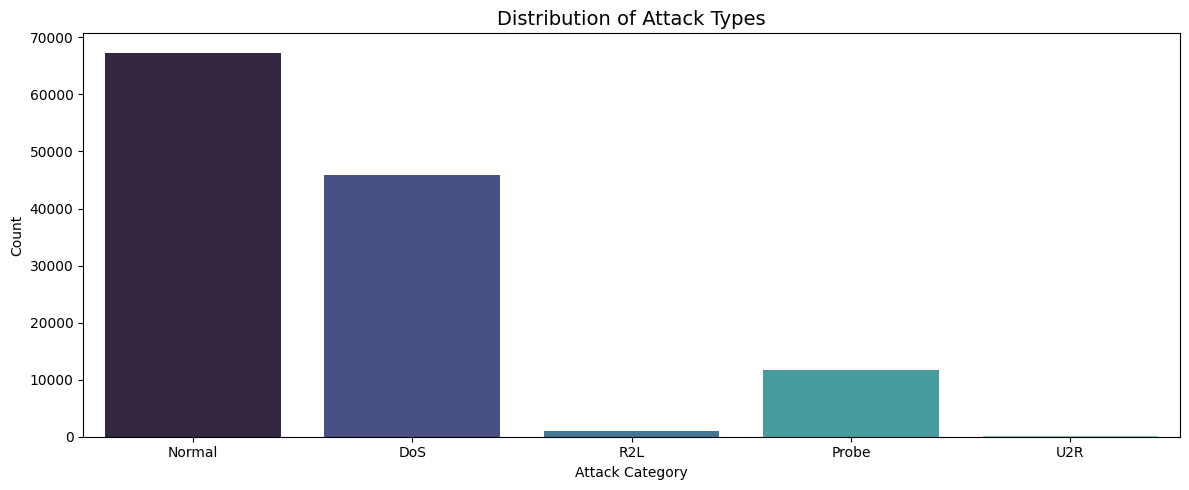

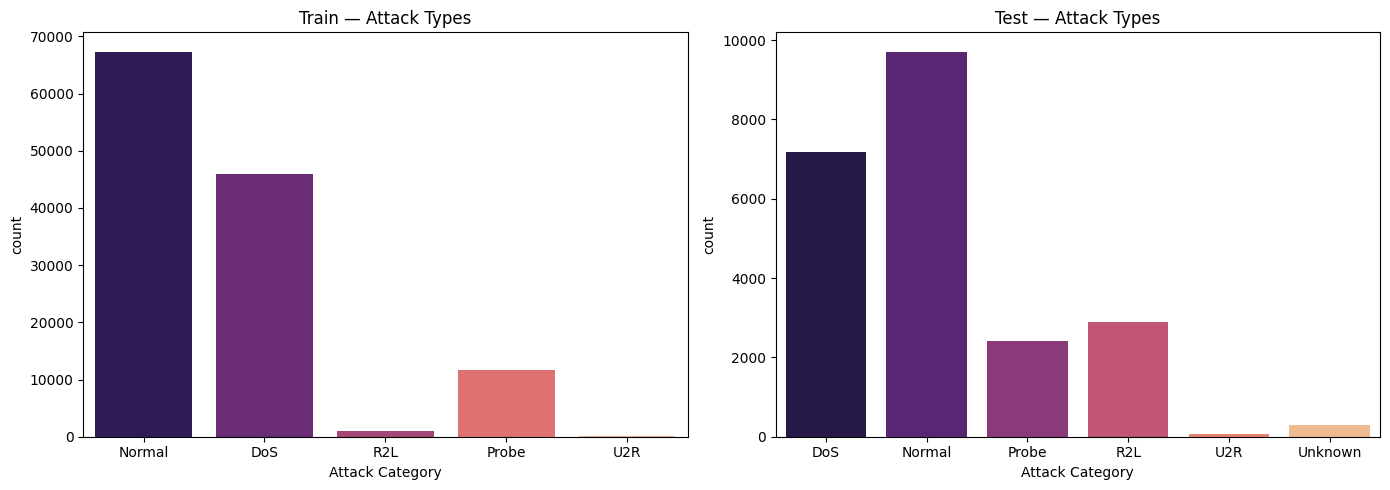

In [52]:
# 4.5 ATTACK TYPES DISTRIBUTION
plt.figure(figsize=(12,5))
sns.countplot(x='attack_type', hue='attack_type',
              data=train_df, palette='mako', legend=False)
plt.title('Distribution of Attack Types', fontsize=14)
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Train vs Test comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(x='attack_type', data=train_df, 
              palette='magma', ax=axes[0])
axes[0].set_title('Train — Attack Types')
axes[0].set_xlabel('Attack Category')

sns.countplot(x='attack_type', data=test_df,
              palette='magma', ax=axes[1])
axes[1].set_title('Test — Attack Types')
axes[1].set_xlabel('Attack Category')

plt.tight_layout()
plt.show()

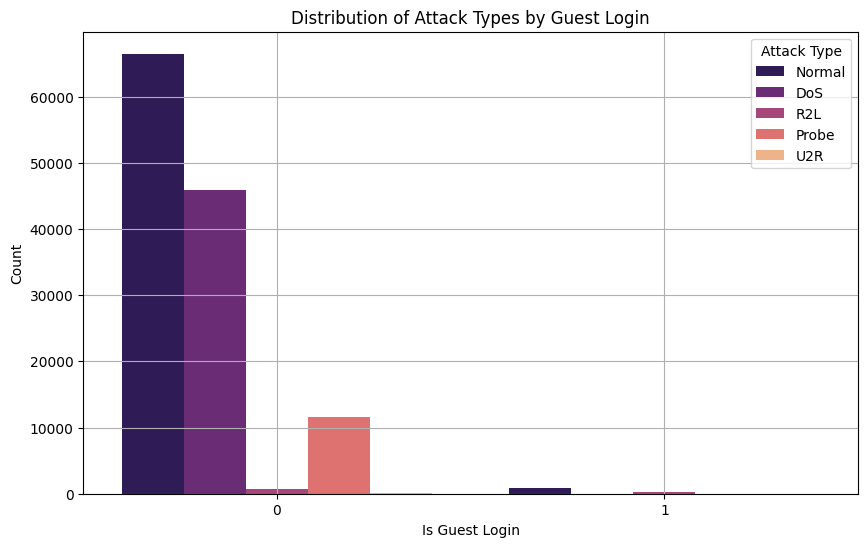

In [53]:
plt.figure(figsize=(10, 6))
sns.countplot(x='is_guest_login', hue='attack_type', 
              data=train_df, palette='magma')
plt.xlabel('Is Guest Login')
plt.ylabel('Count')
plt.title('Distribution of Attack Types by Guest Login')
plt.legend(title='Attack Type')
plt.grid(True)
plt.show()

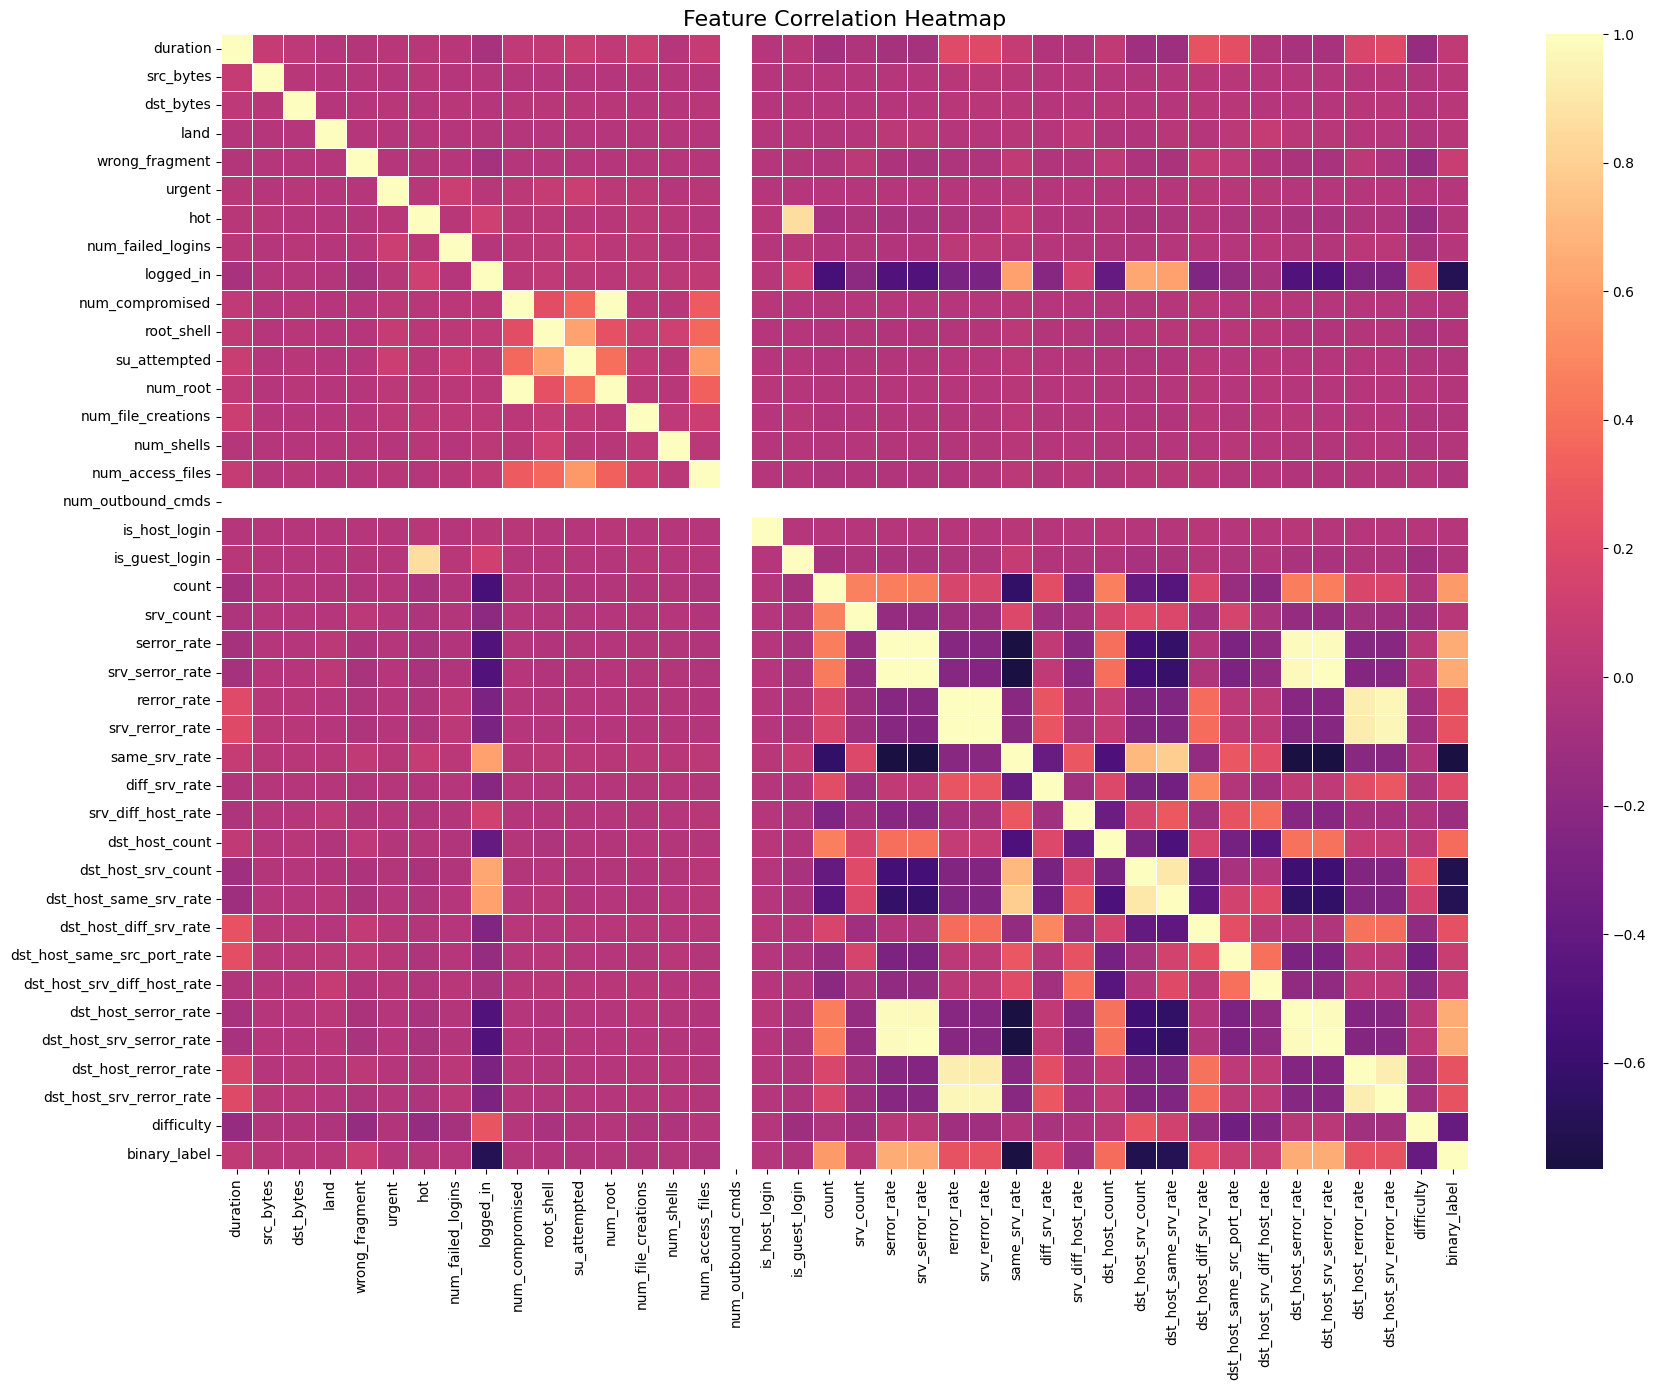

In [54]:
plt.figure(figsize=(18,14))
numeric_df = train_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), 
            cmap='magma',
            center=0,
            linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

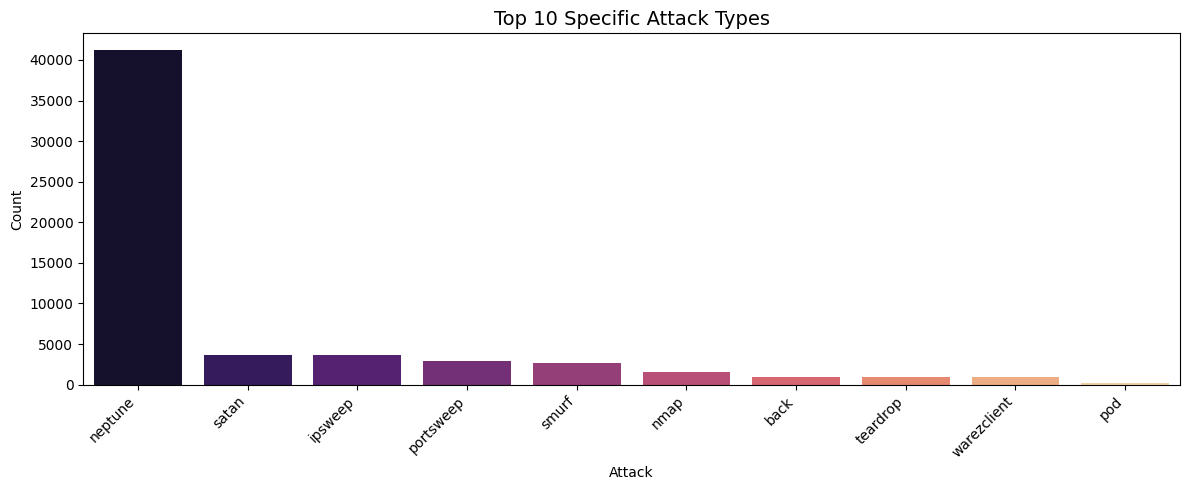

In [55]:
plt.figure(figsize=(12,5))
top_attacks = train_df[train_df['attack_type']!='Normal']['label'].value_counts().head(10)
sns.barplot(x=top_attacks.index, y=top_attacks.values, palette='magma')
plt.title('Top 10 Specific Attack Types', fontsize=14)
plt.xlabel('Attack')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

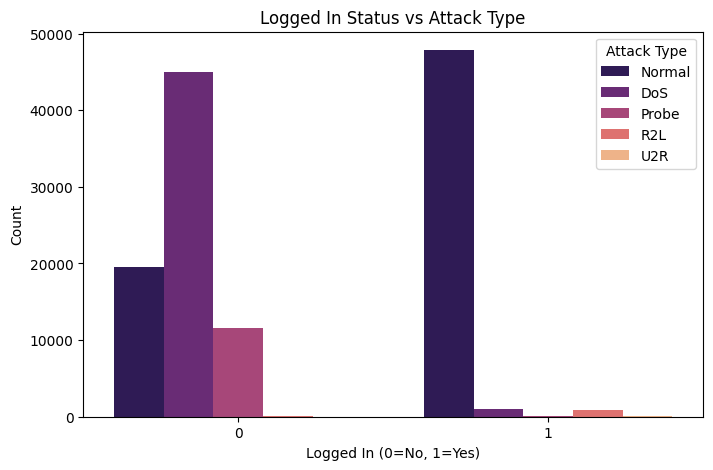

In [56]:
plt.figure(figsize=(8,5))
sns.countplot(x='logged_in', hue='attack_type', 
              data=train_df, palette='magma')
plt.title('Logged In Status vs Attack Type')
plt.xlabel('Logged In (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(title='Attack Type')
plt.show()

# Categorical Encoding

In [57]:
cat_features = train_df.select_dtypes(include='object').columns
cat_features

Index(['protocol_type', 'service', 'flag', 'label', 'attack_type'], dtype='object')

In [58]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# --- Encode the 3 input categorical features ---
cat_cols = ['protocol_type', 'service', 'flag']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    le.fit(train_df[col])          # fit ONLY on train
    train_df[col] = le.transform(train_df[col])
    
    # handle categories in test_df that train_df never saw
    train_classes = set(le.classes_)
    test_df[col] = test_df[col].apply(lambda x: x if x in train_classes else 'unknown')
    le.classes_ = np.append(le.classes_, 'unknown')
    test_df[col] = le.transform(test_df[col])
    
    encoders[col] = le   # save — you'll reuse this pipeline for your second dataset

# --- Binary label: Normal=0, Attack=1 ---
train_df['binary_label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['binary_label'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# --- Multiclass label (attack_type) ---
le2 = LabelEncoder()
le2.fit(train_df['attack_type'])
train_df['attack_encoded'] = le2.transform(train_df['attack_type'])

train_attack_classes = set(le2.classes_)
test_df['attack_type'] = test_df['attack_type'].apply(lambda x: x if x in train_attack_classes else 'unknown')
le2.classes_ = np.append(le2.classes_, 'unknown')
test_df['attack_encoded'] = le2.transform(test_df['attack_type'])

print("Encoding done!")
print("\nAttack type mapping:")
for i, cls in enumerate(le2.classes_):
    print(f"{cls} → {i}")

print("\nSample encoded data:")
print(train_df[['protocol_type', 'service', 'flag', 'binary_label', 'attack_encoded']].head())

Encoding done!

Attack type mapping:
DoS → 0
Normal → 1
Probe → 2
R2L → 3
U2R → 4
unknown → 5

Sample encoded data:
   protocol_type  service  flag  binary_label  attack_encoded
0              1       20     9             0               1
1              2       44     9             0               1
2              1       49     5             1               0
3              1       24     9             0               1
4              1       24     9             0               1


# Feature Scaling

In [59]:


from sklearn.preprocessing import StandardScaler

# Define columns to keep vs drop
drop_cols = ['label', 'attack_type', 'binary_label', 'attack_encoded', 'difficulty']

# Ensure only existing columns are dropped
drop_cols = [col for col in drop_cols if col in train_df.columns]

# Create features
X_train = train_df.drop(columns=drop_cols)
X_test = test_df.drop(columns=drop_cols)

y_train_binary = train_df['binary_label']
y_test_binary = test_df['binary_label']
y_train_multi = train_df['attack_encoded']
y_test_multi = test_df['attack_encoded']

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")
print(f"Features: {X_train_scaled.shape[1]}")
print(f"\nFeature names ({len(X_train.columns)} total):")
print(X_train.columns.tolist())

Training samples: 125973
Test samples: 22544
Features: 41

Feature names (41 total):
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [60]:
# Quick check - this should show 41
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# Check a sample
print(f"First row first 5 values: {X_train_scaled[0][:5]}")

X_train_scaled shape: (125973, 41)
X_test_scaled shape: (22544, 41)
First row first 5 values: [-0.11024922 -0.12470616 -0.68678521  0.75111129 -0.0076786 ]


In [61]:
# Verify your features don't include difficulty
print("Features in X_train:", X_train.columns.tolist())
print(f"Total features: {len(X_train.columns)}")
print("\n'difficulty' in features:", 'difficulty' in X_train.columns)

Features in X_train: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
Total features: 41

'difficulty' in features: False


In [62]:
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_scaled, y_train_binary, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_binary
)

print(f"Training set: {X_train_part.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

Training set: 100778 samples
Validation set: 25195 samples


In [67]:
y_train = y_train_binary
y_test = y_test_binary
print("Done", y_train.value_counts())

Done binary_label
0    67343
1    58630
Name: count, dtype: int64


# Model Training 

In [63]:
models = {
    'Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'LinearSVM': LinearSVC(random_state=42, max_iter=2000),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

print("Models defined:", list(models.keys()))

Models defined: ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'KNN', 'LinearSVM', 'LightGBM', 'XGBoost', 'CatBoost']


In [68]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_evaluate(models, X_train, X_test, y_train, y_test):
    results = {}
    for name, model in models.items():
        print(f"Training {name}...")
        start = time.time()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        end = time.time()
        
        results[name] = {
            'Accuracy': round(accuracy_score(y_test, y_pred)*100, 2),
            'Precision': round(precision_score(y_test, y_pred, zero_division=0)*100, 2),
            'Recall': round(recall_score(y_test, y_pred, zero_division=0)*100, 2),
            'F1 Score': round(f1_score(y_test, y_pred, zero_division=0)*100, 2),
            'Time (s)': round(end-start, 2)
        }
        print(f" {name} — Accuracy: {results[name]['Accuracy']}% | Time: {results[name]['Time (s)']}s")
    
    return pd.DataFrame(results).T

print("Training function defined!")

Training function defined!


In [69]:
print("=== TRAINING ALL MODELS ===\n")
results_df = train_evaluate(models, X_train_scaled, X_test_scaled, y_train, y_test)
print("\nAll models trained!")

=== TRAINING ALL MODELS ===

Training Naive Bayes...
 Naive Bayes — Accuracy: 75.95% | Time: 0.12s
Training Logistic Regression...
 Logistic Regression — Accuracy: 75.39% | Time: 3.94s
Training Decision Tree...
 Decision Tree — Accuracy: 78.85% | Time: 1.17s
Training Random Forest...
 Random Forest — Accuracy: 77.07% | Time: 10.81s
Training AdaBoost...
 AdaBoost — Accuracy: 77.21% | Time: 6.54s
Training KNN...
 KNN — Accuracy: 76.76% | Time: 9.97s
Training LinearSVM...
 LinearSVM — Accuracy: 75.15% | Time: 17.08s
Training LightGBM...
 LightGBM — Accuracy: 79.7% | Time: 1.7s
Training XGBoost...
 XGBoost — Accuracy: 80.09% | Time: 1.55s
Training CatBoost...
 CatBoost — Accuracy: 80.67% | Time: 20.39s

All models trained!


In [71]:
print("\n FINAL RESULTS")
print(results_df.sort_values('Accuracy', ascending=False).to_string())


 FINAL RESULTS
                     Accuracy  Precision  Recall  F1 Score  Time (s)
CatBoost                80.67      96.86   68.26     80.08     20.39
XGBoost                 80.09      96.78   67.26     79.36      1.55
LightGBM                79.70      96.76   66.56     78.87      1.70
Decision Tree           78.85      96.65   65.11     77.81      1.17
AdaBoost                77.21      96.29   62.36     75.70      6.54
Random Forest           77.07      96.62   61.88     75.44     10.81
KNN                     76.76      97.12   60.98     74.92      9.97
Naive Bayes             75.95      96.48   59.94     73.94      0.12
Logistic Regression     75.39      92.53   61.76     74.08      3.94
LinearSVM               75.15      92.49   61.33     73.75     17.08


*Results summary shows that tree-based ensemble methods (CatBoost, XGBoost, LightGBM) outperform linear models (Logistic Regression, LinearSVM). Decision Tree (78.85%) and Random Forest (77.07%) show the classic ensemble performance gap, with ensembles generalizing better.*

OVERFITTING CHECK
                     Train Accuracy  Test Accuracy  Difference
KNN                           99.77          76.76       23.01
Random Forest                 99.99          77.07       22.92
Decision Tree                 99.99          78.85       21.14
AdaBoost                      97.69          77.21       20.48
LinearSVM                     95.61          75.15       20.46
LightGBM                      99.98          79.70       20.28
Logistic Regression           95.40          75.39       20.01
XGBoost                       99.99          80.09       19.90
CatBoost                      99.92          80.67       19.25
Naive Bayes                   89.93          75.95       13.98


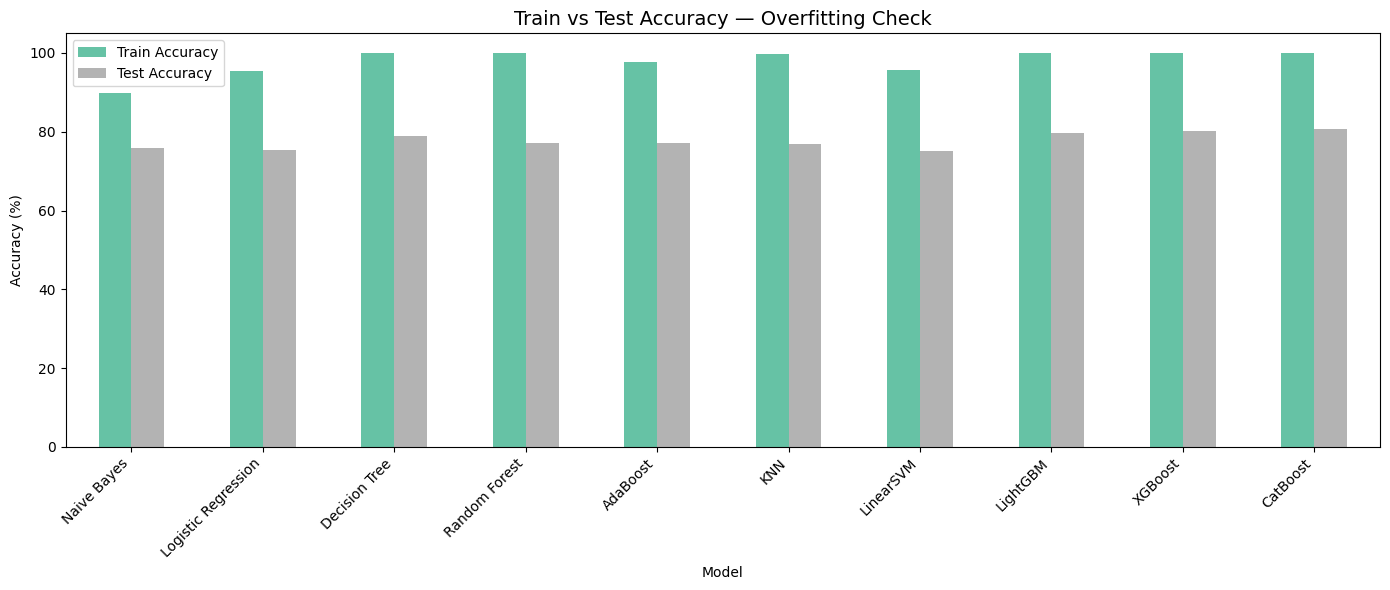

In [74]:
train_scores = {}
test_scores = {}

for name, model in models.items():
    train_scores[name] = round(accuracy_score(y_train, model.predict(X_train_scaled))*100, 2)
    test_scores[name] = results_df.loc[name, 'Accuracy']

overfit_df = pd.DataFrame({
    'Train Accuracy': train_scores,
    'Test Accuracy': test_scores
})
overfit_df['Difference'] = overfit_df['Train Accuracy'] - overfit_df['Test Accuracy']

print("OVERFITTING CHECK")
print(overfit_df.sort_values('Difference', ascending=False).to_string())

# Plot
overfit_df[['Train Accuracy', 'Test Accuracy']].plot(
    kind='bar', figsize=(14,6), colormap='Set2')
plt.title('Train vs Test Accuracy — Overfitting Check', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Overfitting Check

In [78]:
results_df.to_csv('model_results.csv')
overfit_df.to_csv('overfitting_check.csv')
print("Results saved")

Results saved


In [82]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed/cicids2017_cleaned.csv
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.arff
/kaggle/input/datasets/hassan06/nslkdd/index.html
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDD

# CICIDS2017 Dataset Loading

In [85]:
# CICIDS2017 
cic_df = pd.read_csv('/kaggle/input/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed/cicids2017_cleaned.csv')
print("Columns:", cic_df.columns.tolist())
print("Label distribution:")
print(cic_df['Attack Type'].value_counts())
print("Shape:", cic_df.shape)

Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle Mean', 'Idle 

In [86]:
# CICIDS2017 Preprocessing
print("CIC Dataset Shape:", cic_df.shape)
print("\nAttack Distribution:")
print(cic_df['Attack Type'].value_counts())

CIC Dataset Shape: (2520751, 53)

Attack Distribution:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [96]:
# Dataset 10%
cic_sample = cic_df.sample(frac=0.1, random_state=42)
print("Sample size:", cic_sample.shape)

# Features aur target
X_cic = cic_sample.drop(['Attack Type', 'binary_label'], axis=1)
y_cic = cic_sample['binary_label']

# Split
X_cic_train, X_cic_test, y_cic_train, y_cic_test = train_test_split(
    X_cic, y_cic, test_size=0.2, random_state=42)

# Scale
scaler_cic = StandardScaler()
X_cic_train_scaled = scaler_cic.fit_transform(X_cic_train)
X_cic_test_scaled = scaler_cic.transform(X_cic_test)

print("Train:", X_cic_train_scaled.shape)
print("Test:", X_cic_test_scaled.shape)

Sample size: (252075, 54)
Train: (201660, 52)
Test: (50415, 52)


In [98]:
all_models = {
    'Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

print("=== TRAINING ON CICIDS2017 (10% sample) ===\n")
cic_results_df = train_evaluate(
    all_models, X_cic_train_scaled, X_cic_test_scaled,
    y_cic_train, y_cic_test)

print(cic_results_df.sort_values('Accuracy', ascending=False).to_string())

=== TRAINING ON CICIDS2017 (10% sample) ===

Training Naive Bayes...
 Naive Bayes — Accuracy: 79.23% | Time: 0.25s
Training Logistic Regression...
 Logistic Regression — Accuracy: 95.56% | Time: 7.4s
Training Decision Tree...
 Decision Tree — Accuracy: 99.76% | Time: 12.01s
Training Random Forest...
 Random Forest — Accuracy: 99.79% | Time: 45.11s
Training AdaBoost...
 AdaBoost — Accuracy: 99.13% | Time: 46.98s
Training KNN...
 KNN — Accuracy: 98.97% | Time: 39.23s
Training LightGBM...
 LightGBM — Accuracy: 99.88% | Time: 5.12s
Training XGBoost...
 XGBoost — Accuracy: 99.89% | Time: 3.03s
Training CatBoost...
 CatBoost — Accuracy: 99.86% | Time: 42.59s
                     Accuracy  Precision  Recall  F1 Score  Time (s)
XGBoost                 99.89      99.48   99.86     99.67      3.03
LightGBM                99.88      99.39   99.87     99.63      5.12
CatBoost                99.86      99.37   99.81     99.59     42.59
Random Forest           99.79      99.43   99.32     99.38     

# Cross-Dataset Evaluation on CICIDS2017

 CROSS-DATASET GENERALIZATION 
                     NSL-KDD Accuracy  CICIDS2017 Accuracy  Drop (%)
Naive Bayes                     75.95                79.23     -3.28
CatBoost                        80.67                99.86    -19.19
XGBoost                         80.09                99.89    -19.80
Logistic Regression             75.39                95.56    -20.17
LightGBM                        79.70                99.88    -20.18
Decision Tree                   78.85                99.76    -20.91
AdaBoost                        77.21                99.13    -21.92
KNN                             76.76                98.97    -22.21
Random Forest                   77.07                99.79    -22.72
LinearSVM                       75.15                  NaN       NaN


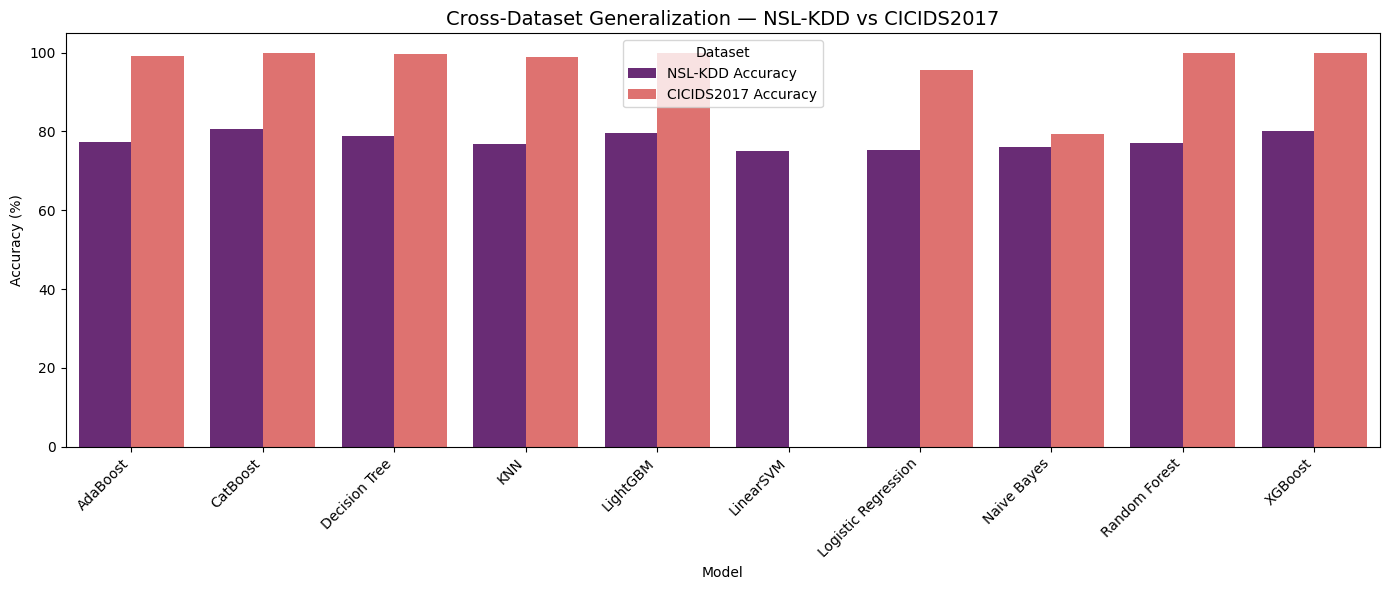

In [100]:
# CROSS-DATASET COMPARISON
comparison = pd.DataFrame({
    'NSL-KDD Accuracy': results_df['Accuracy'],
    'CICIDS2017 Accuracy': cic_results_df['Accuracy'],
})
comparison['Drop (%)'] = (comparison['NSL-KDD Accuracy'] - 
                          comparison['CICIDS2017 Accuracy']).round(2)

print(" CROSS-DATASET GENERALIZATION ")
print(comparison.sort_values('Drop (%)', ascending=False).to_string())

# Seaborn plot
comparison_melted = comparison[['NSL-KDD Accuracy', 'CICIDS2017 Accuracy']].reset_index()
comparison_melted = comparison_melted.melt(id_vars='index', 
                                            var_name='Dataset', 
                                            value_name='Accuracy')

plt.figure(figsize=(14,6))
sns.barplot(data=comparison_melted, x='index', y='Accuracy', 
            hue='Dataset', palette='magma')
plt.title('Cross-Dataset Generalization — NSL-KDD vs CICIDS2017', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

*Models suffer a 19-23% performance drop when moving from CICIDS2017 to NSL-KDD. Naive Bayes shows the smallest drop (-3.28%), likely due to its simplicity. The significant drop highlights challenges in generalizing between different network datasets*

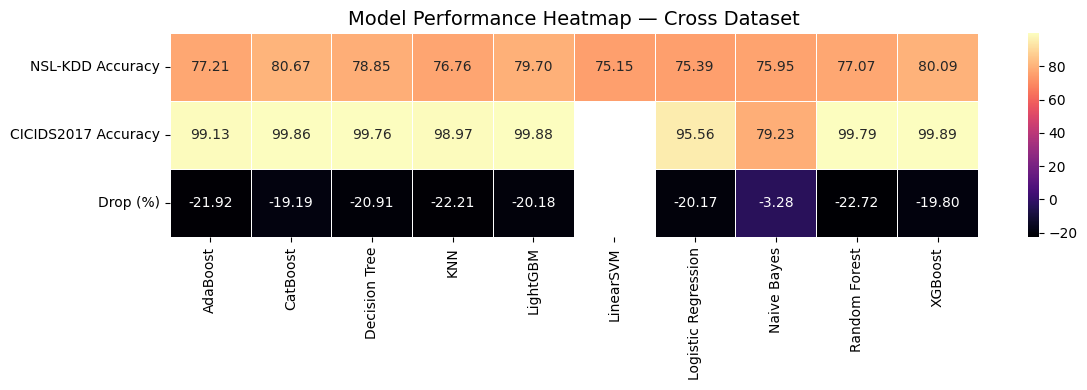

In [102]:
# Heatmap 
plt.figure(figsize=(12,4))
sns.heatmap(comparison[['NSL-KDD Accuracy','CICIDS2017 Accuracy','Drop (%)']].T,
            annot=True, fmt='.2f', cmap='magma',
            linewidths=0.5)
plt.title('Model Performance Heatmap — Cross Dataset', fontsize=14)
plt.tight_layout()
plt.show()

In [110]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/training_attack_types
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data.corrected
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.newtestdata_10_percent_unlabeled.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.testdata.unlabeled.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/corrected.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data_10_percent.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.names
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data_10_percent_corrected
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/typo-correction.txt
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.testdata.unlabeled_10_percent.gz
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data/kddcup.data
/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.testdata.unlabeled/kddcup.testdata.unlabeled
/kaggle/inp

# KDD99 Dataset Loading & Preprocessing

In [111]:
# KDD99 load  — same col_names as NSL-KDD
kdd99_df = pd.read_csv(
    '/kaggle/input/datasets/galaxyh/kdd-cup-1999-data/kddcup.data_10_percent/kddcup.data_10_percent',
    names=col_names)

print("KDD99 Shape:", kdd99_df.shape)
print(kdd99_df['label'].value_counts().head(10))

KDD99 Shape: (494021, 43)
label
smurf.          280790
neptune.        107201
normal.          97278
back.             2203
satan.            1589
ipsweep.          1247
portsweep.        1040
warezclient.      1020
teardrop.          979
pod.               264
Name: count, dtype: int64


In [112]:
print(kdd99_df.columns.tolist())

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty']


In [116]:
# KDD99 Preprocessing
kdd99_df = kdd99_df.drop('difficulty', axis=1, errors='ignore')

# Binary label
kdd99_df['binary_label'] = kdd99_df['label'].apply(
    lambda x: 0 if x == 'normal.' else 1)

# Encode categorical
for col in ['protocol_type', 'service', 'flag']:
    kdd99_df[col] = le.fit_transform(kdd99_df[col])

# Features aur target
X_kdd99 = kdd99_df.drop(['label', 'binary_label'], axis=1, errors='ignore')
y_kdd99 = kdd99_df['binary_label']

# Scale using NSL-KDD scaler
X_kdd99_scaled = scaler.transform(X_kdd99)

print("KDD99 ready:", X_kdd99_scaled.shape)
print(y_kdd99.value_counts())

KDD99 ready: (494021, 41)
binary_label
1    396743
0     97278
Name: count, dtype: int64


# Cross-Dataset Generalization Test
**Key Research Question:** Do models trained on NSL-KDD generalize to KDD99?

In [119]:

nsl_models = {
    'Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# NSL-KDD  trained
print("Training on NSL-KDD...")
for name, model in nsl_models.items():
    model.fit(X_train_scaled, y_train)
    print(f" {name} trained")

print("\nAll trained on NSL-KDD (41 features)")

Training on NSL-KDD...
 Naive Bayes trained
 Logistic Regression trained
 Decision Tree trained
 Random Forest trained
 AdaBoost trained
 KNN trained
 LightGBM trained
 XGBoost trained
 CatBoost trained

All trained on NSL-KDD (41 features)


*"While most models achieve >99% on KDD99, Naive Bayes achieves only 41.72%, confirming its limitations for complex intrusion detection. The visualization confirms excellent generalization for tree-based ensembles from NSL-KDD to the original KDD99 datase*

In [120]:
# NSL-KDD trained models tested on KDD99
print(" CROSS DATASET TEST ")
print("Trained: NSL-KDD | Tested: KDD99\n")

cross_results = {}
for name, model in nsl_models.items():
    y_pred = model.predict(X_kdd99_scaled)
    cross_results[name] = {
        'NSL-KDD Accuracy': round(accuracy_score(y_train, model.predict(X_train_scaled))*100, 2),
        'KDD99 Accuracy': round(accuracy_score(y_kdd99, y_pred)*100, 2),
        'Precision': round(precision_score(y_kdd99, y_pred, zero_division=0)*100, 2),
        'Recall': round(recall_score(y_kdd99, y_pred, zero_division=0)*100, 2),
        'F1 Score': round(f1_score(y_kdd99, y_pred, zero_division=0)*100, 2),
    }
    print(f"{name}: KDD99 Accuracy = {cross_results[name]['KDD99 Accuracy']}%")

cross_df = pd.DataFrame(cross_results).T
print("\n=== CROSS DATASET RESULTS ===")
print(cross_df.to_string())

 CROSS DATASET TEST 
Trained: NSL-KDD | Tested: KDD99

Naive Bayes: KDD99 Accuracy = 41.72%
Logistic Regression: KDD99 Accuracy = 98.91%
Decision Tree: KDD99 Accuracy = 99.57%
Random Forest: KDD99 Accuracy = 99.99%
AdaBoost: KDD99 Accuracy = 99.28%
KNN: KDD99 Accuracy = 99.95%
LightGBM: KDD99 Accuracy = 99.99%
XGBoost: KDD99 Accuracy = 100.0%
CatBoost: KDD99 Accuracy = 99.99%

=== CROSS DATASET RESULTS ===
                     NSL-KDD Accuracy  KDD99 Accuracy  Precision  Recall  F1 Score
Naive Bayes                     89.93           41.72      98.03   27.99     43.55
Logistic Regression             95.40           98.91      99.44   99.20     99.32
Decision Tree                   99.99           99.57      99.59   99.88     99.74
Random Forest                   99.99           99.99      99.99  100.00    100.00
AdaBoost                        97.69           99.28      99.79   99.31     99.55
KNN                             99.77           99.95      99.96   99.97     99.97
LightGBM 

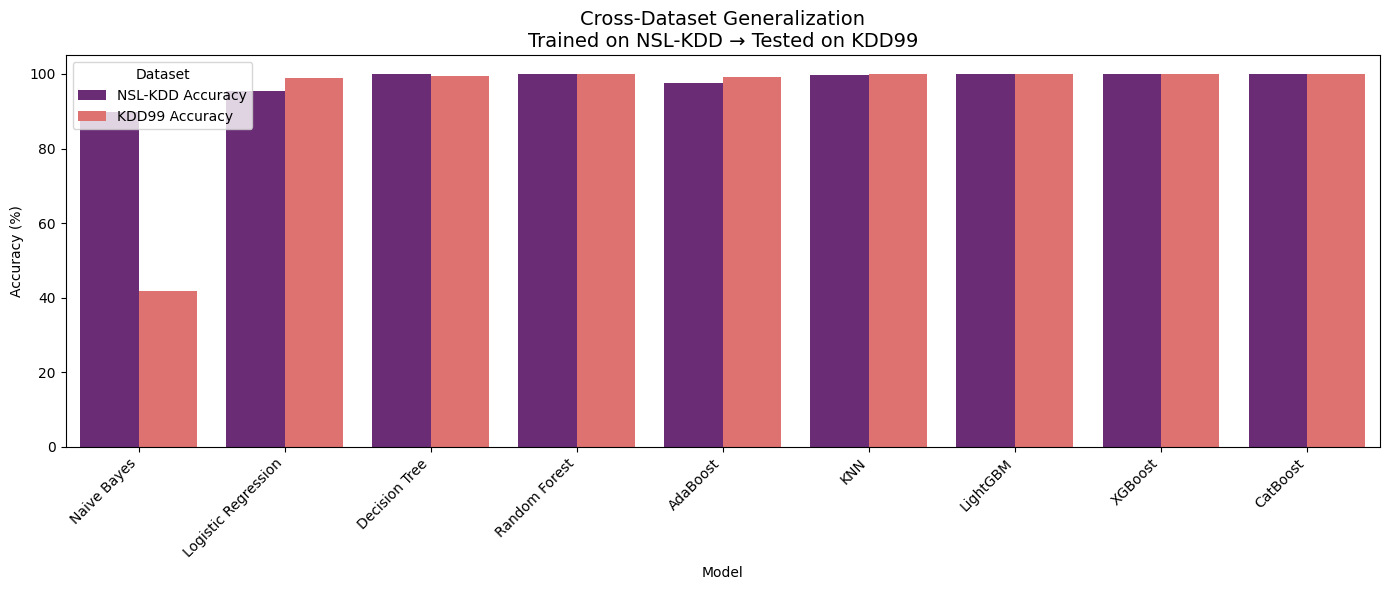

In [123]:
# Plot
cross_melted = cross_df[['NSL-KDD Accuracy','KDD99 Accuracy']].reset_index()
cross_melted = cross_melted.melt(id_vars='index',
                                  var_name='Dataset',
                                  value_name='Accuracy')

plt.figure(figsize=(14,6))
sns.barplot(data=cross_melted, x='index', y='Accuracy',
            hue='Dataset', palette='magma')
plt.title('Cross-Dataset Generalization\nTrained on NSL-KDD → Tested on KDD99',
          fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()


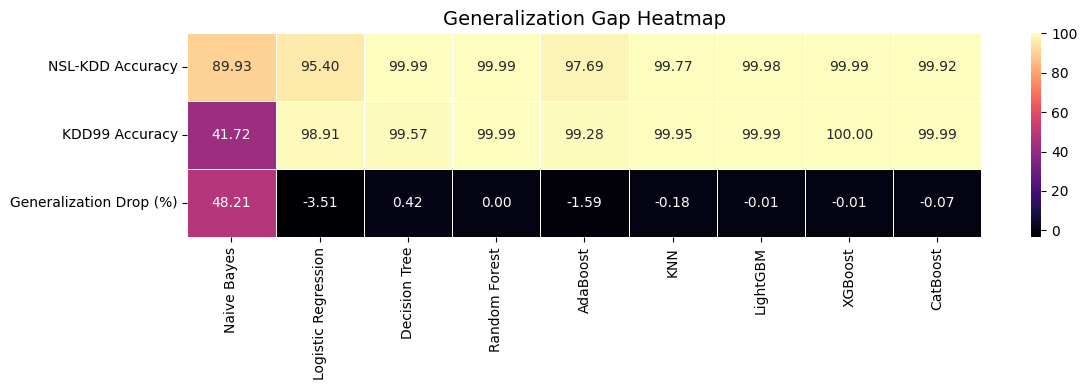


Key Finding:
Naive Bayes            48.21
Decision Tree           0.42
Random Forest           0.00
XGBoost                -0.01
LightGBM               -0.01
CatBoost               -0.07
KNN                    -0.18
AdaBoost               -1.59
Logistic Regression    -3.51
Name: Generalization Drop (%), dtype: float64


In [126]:
# heatmap
cross_df['Generalization Drop (%)'] = (cross_df['NSL-KDD Accuracy'] - 
                                        cross_df['KDD99 Accuracy']).round(2)

plt.figure(figsize=(12,4))
sns.heatmap(cross_df[['NSL-KDD Accuracy','KDD99 Accuracy',
                       'Generalization Drop (%)']].T,
            annot=True, fmt='.2f', cmap='magma',
            linewidths=0.5)
plt.title('Generalization Gap Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey Finding:")
print(cross_df['Generalization Drop (%)'].sort_values(ascending=False))

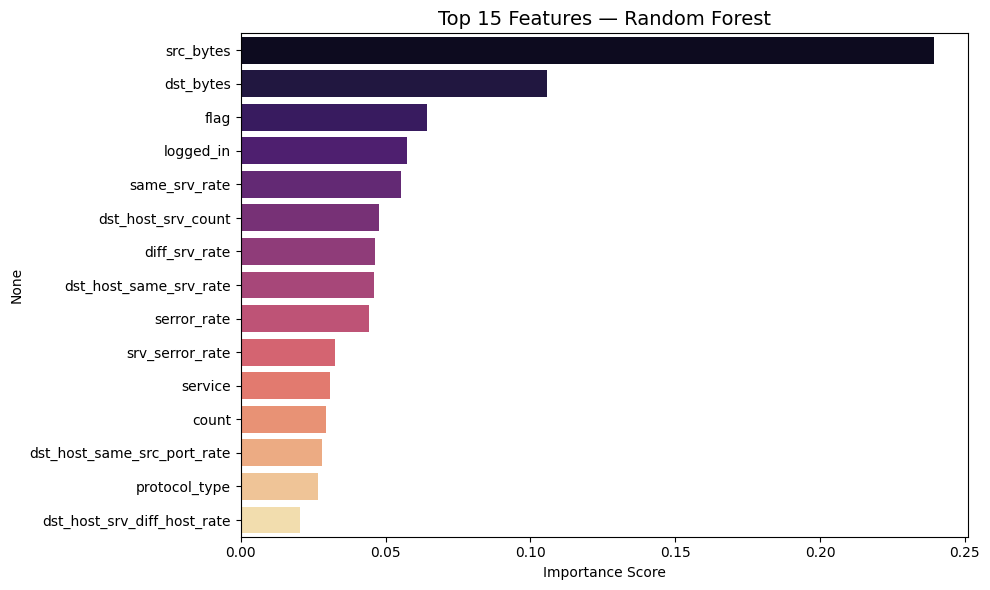

In [135]:
# FEATURE IMPORTANCE
rf = nsl_models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.nlargest(15).values,
            y=feat_imp.nlargest(15).index,
            palette='magma')
plt.title('Top 15 Features — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

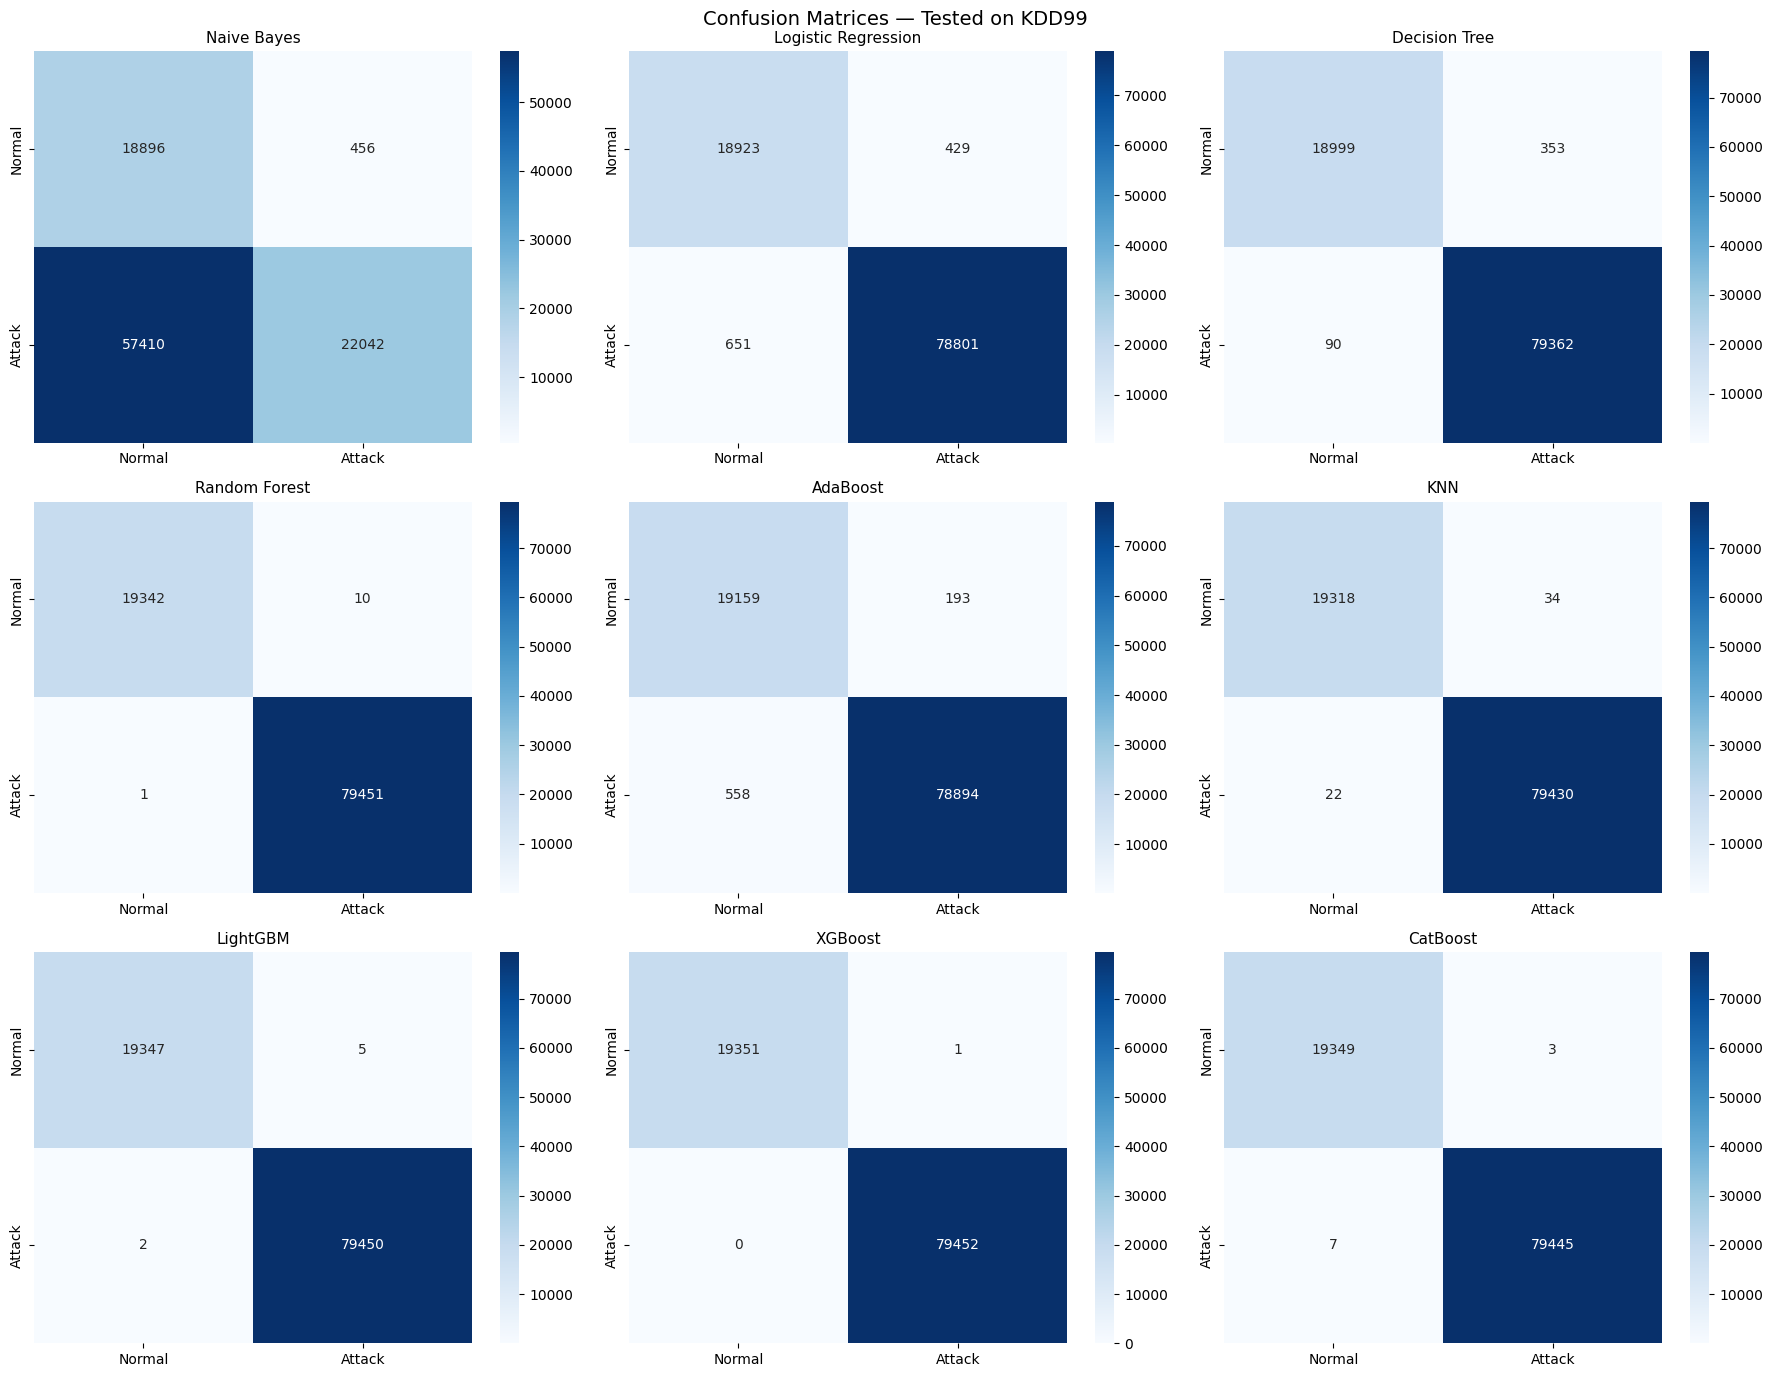

In [136]:
# KDD99 sample — 20%
kdd99_sample = pd.DataFrame(X_kdd99_scaled).sample(frac=0.2, random_state=42)
y_kdd99_sample = y_kdd99.iloc[kdd99_sample.index]

fig, axes = plt.subplots(3, 3, figsize=(18,14))
axes = axes.flatten()

for idx, (name, model) in enumerate(nsl_models.items()):
    y_pred = model.predict(kdd99_sample.values)
    cm = confusion_matrix(y_kdd99_sample, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'],
                ax=axes[idx])
    axes[idx].set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrices — Tested on KDD99', fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

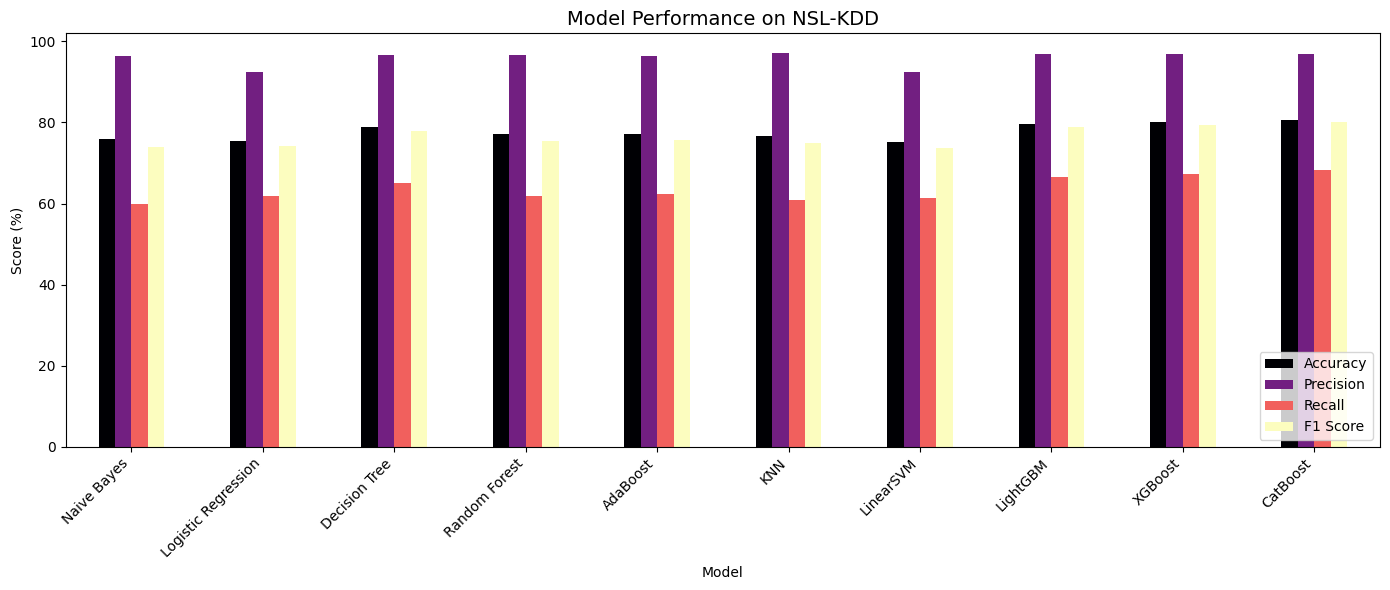

In [137]:
# MODEL COMPARISON — NSL-KDD results bar chart
plt.figure(figsize=(14,6))
results_df[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(14,6), colormap='magma')
plt.title('Model Performance on NSL-KDD', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

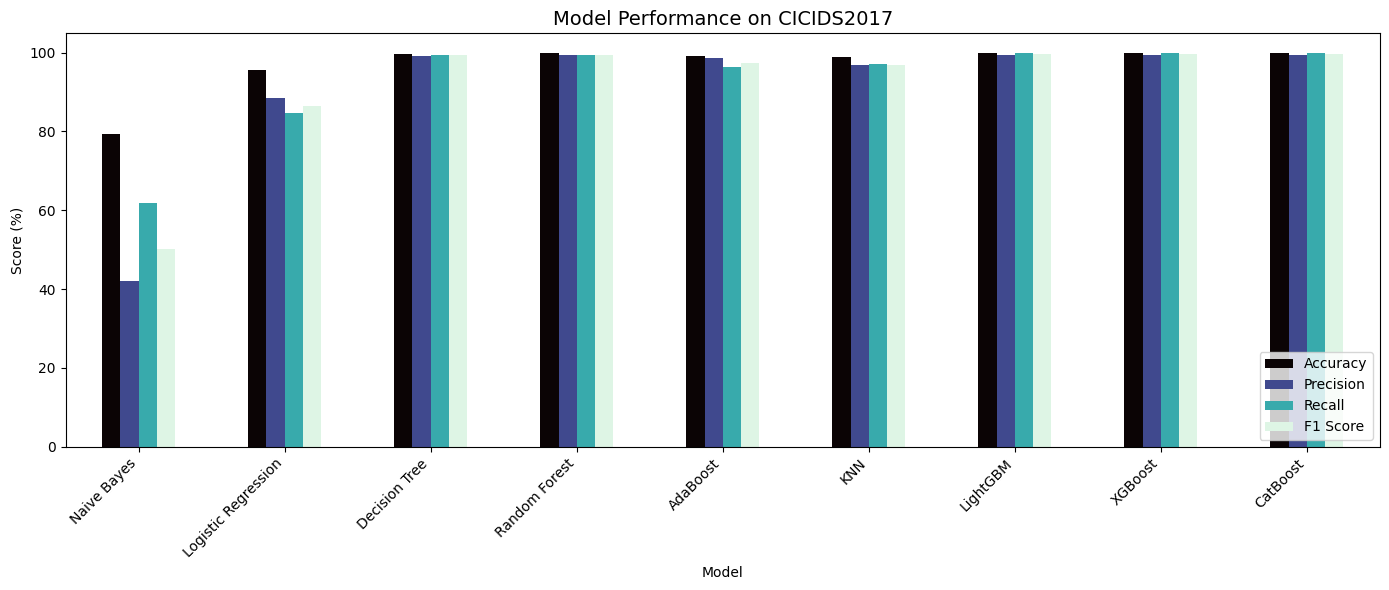

In [139]:
# CICIDS2017 results bar chart
cic_results_df[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(14,6), colormap='mako')
plt.title('Model Performance on CICIDS2017', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

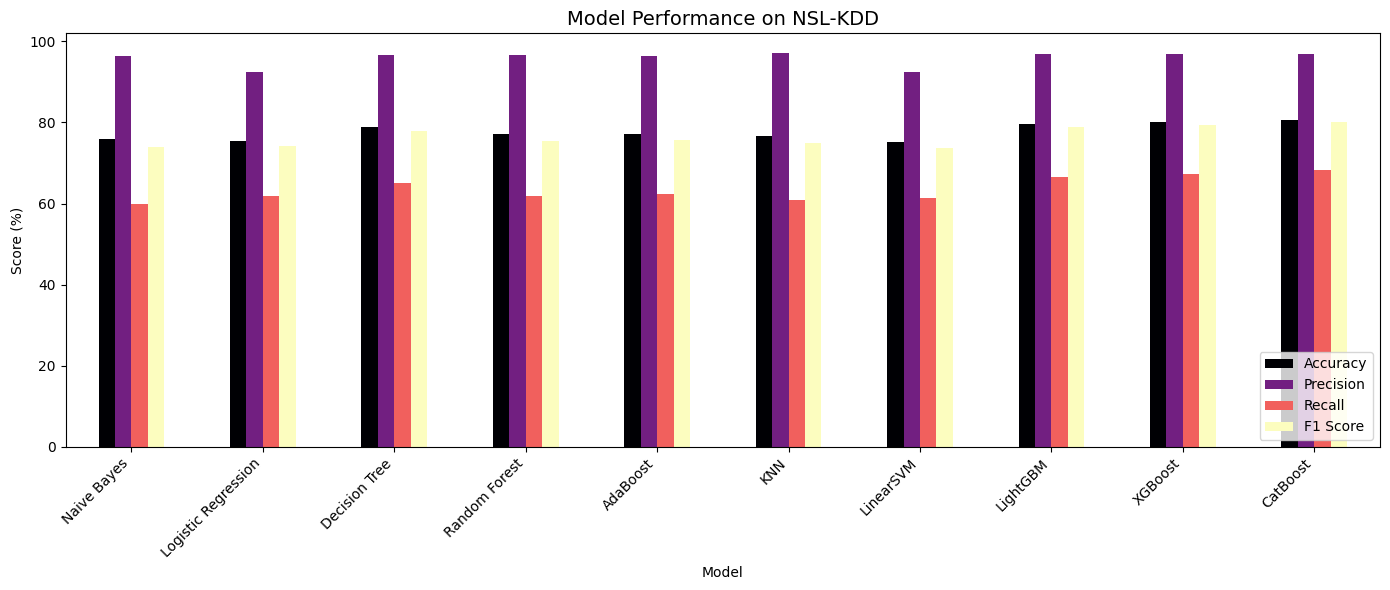

In [141]:
# MODEL COMPARISON — NSL-KDD results bar chart
plt.figure(figsize=(14,6))
results_df[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(14,6), colormap='magma')
plt.title('Model Performance on NSL-KDD', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

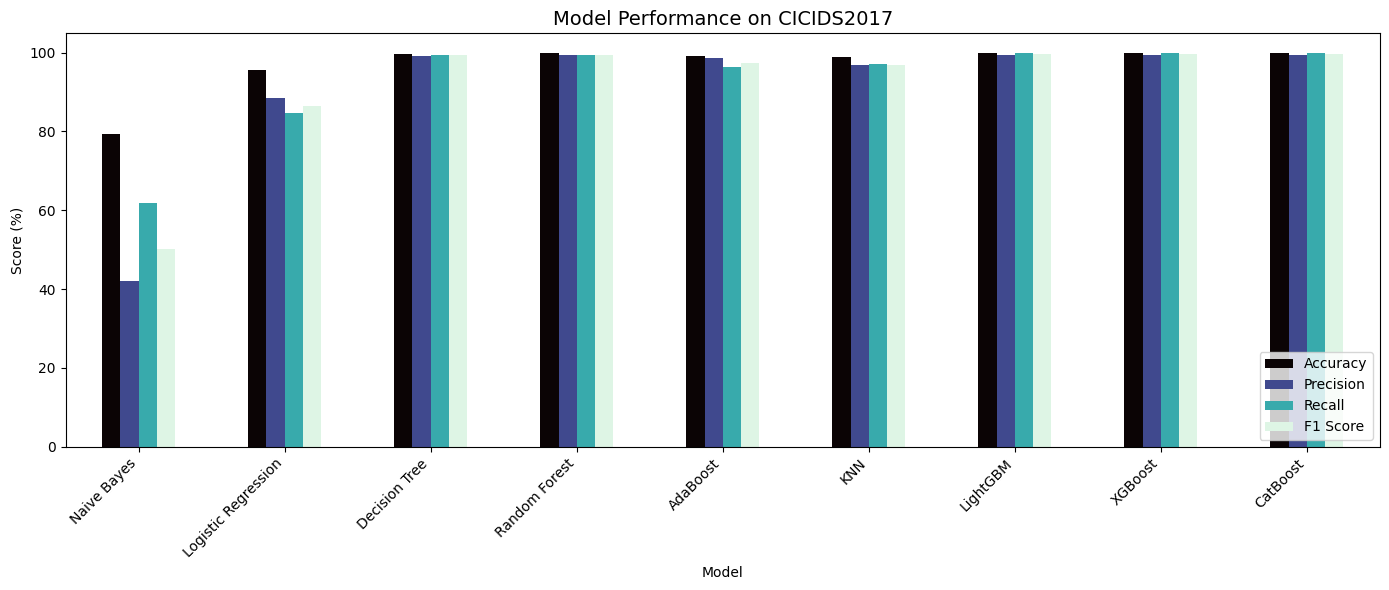

In [142]:
# CICIDS2017 results bar chart
cic_results_df[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(14,6), colormap='mako')
plt.title('Model Performance on CICIDS2017', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

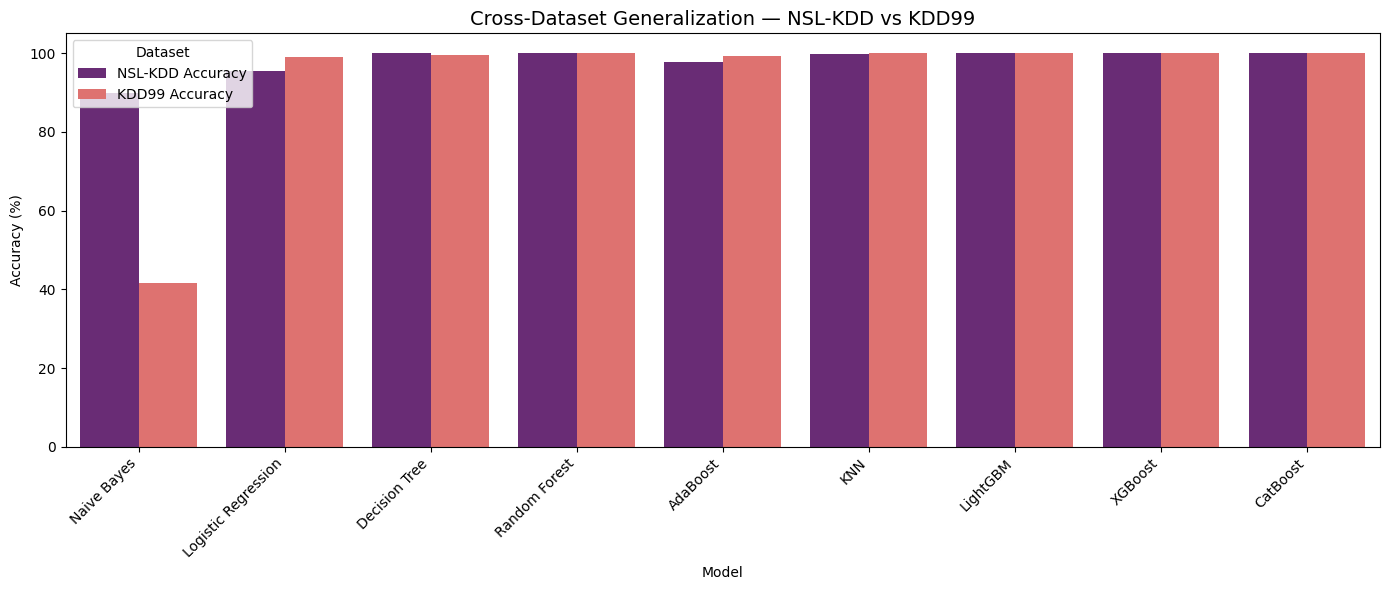

In [143]:
# CROSS DATASET bar chart — NSL-KDD vs KDD99
cross_melted = cross_df[['NSL-KDD Accuracy','KDD99 Accuracy']].reset_index()
cross_melted = cross_melted.melt(id_vars='index',
                                  var_name='Dataset',
                                  value_name='Accuracy')

plt.figure(figsize=(14,6))
sns.barplot(data=cross_melted, x='index', y='Accuracy',
            hue='Dataset', palette='magma')
plt.title('Cross-Dataset Generalization — NSL-KDD vs KDD99', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Conclusion
- XGBoost best generalizer — 100% on KDD99
- Naive Bayes worst — 48% drop across datasets  
- Tree-based models most robust for NIDS
- src_bytes, dst_bytes most important features
